In [2]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.stats import binned_statistic, binned_statistic_2d
from src.loading import (
    load_gpm_feature_stats,
    load_imerg_feature_stats,
    load_dyamond_feature_stats,
    load_archived_dyamond_feature_stats,
     load_pickled_archived_features,
    SATURATED_MAXPR_MIN
)
from src.plotting import (
    array_midpoints,
    discrete_cmap,
    plot_mean_stat,
    gpm_area_factor,
    gpm_area_factor_accurate,
    plot_mean_stat
)
from src.binned_analysis import (
    BinnedQuantileDelta,
    BinnedTLSSlope
)
from src.saving import save_figure, save_table

# Distributions of Feature Morphology

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_GPM_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_GPM_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_GEOS_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_GEOS_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_SCREAM_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_SCREAM_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_SHiELD_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_SHiELD_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_MPAS_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_MPAS_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_gSAM_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_gSAM_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_ICON_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...


...

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_GEOS_EdgeFracMax0.5_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_GEOS_EdgeFracMax0.5_Res_0.05_Accum_15min_colorbar.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_SCREAM_EdgeFracMax0.5_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_SCREAM_EdgeFracMax0.5_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_SHiELD_EdgeFracMax0.5_Res_0.05_Accum_15min.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_SHiELD_EdgeFracMax0.5_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_MPAS_EdgeFracMax0.5_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_MPAS_EdgeFracMax0.5_Res_0.05_Accum_15min_colorbar.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_gSAM_EdgeFracMax0.5_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_gSAM_EdgeFracMax0.5_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_ICON_EdgeFracMax0.5_Res_0.05_Accum_15min.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_PDF_ICON_EdgeFracMax0.5_Res_0.05_Accum_15min_colorbar.pdf as PDF ...


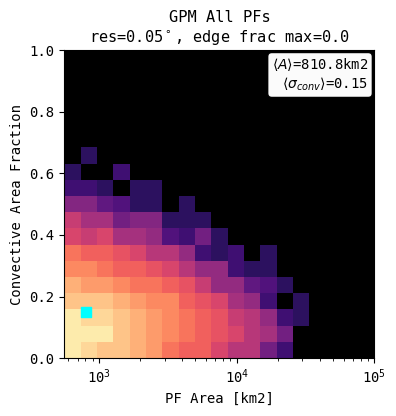

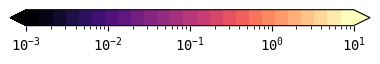

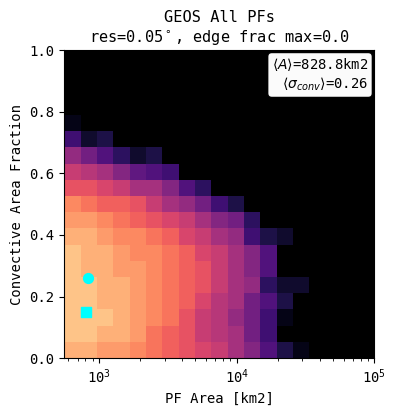

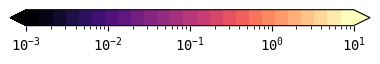

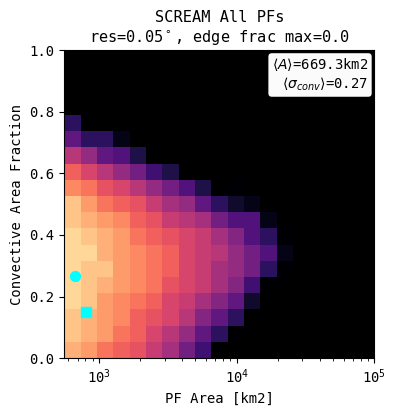

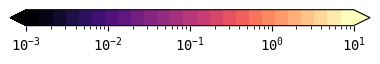

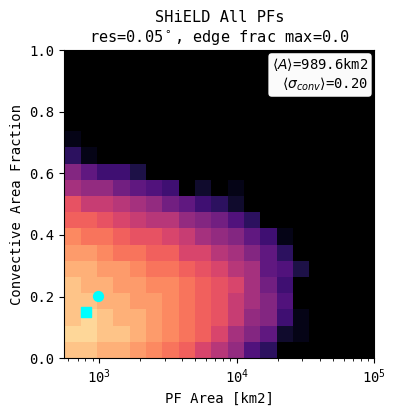

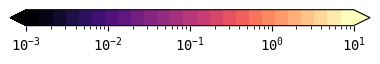

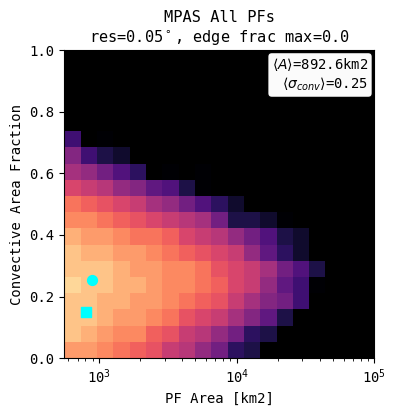

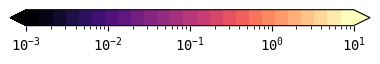

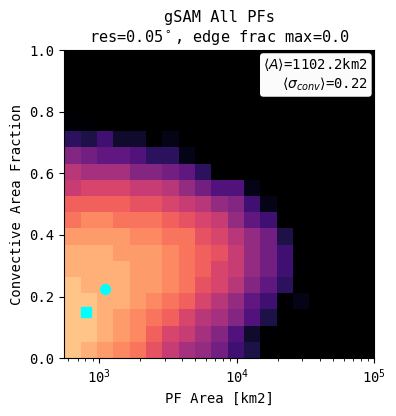

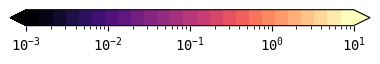

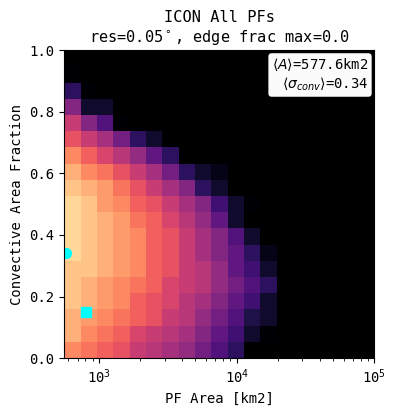

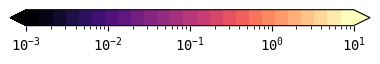

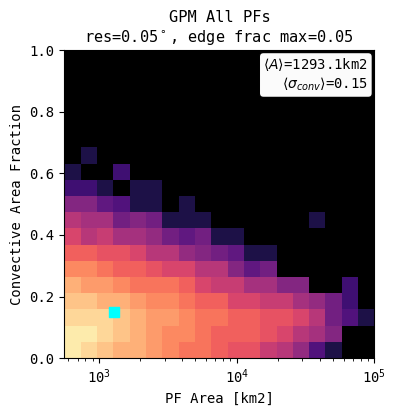

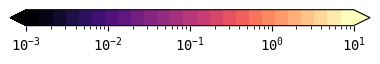

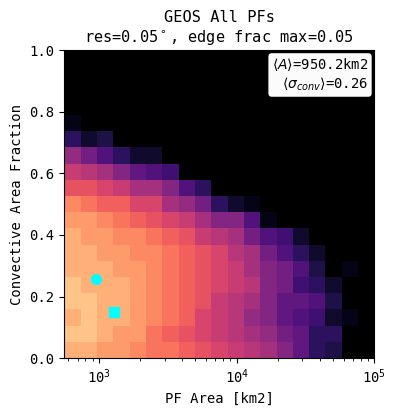

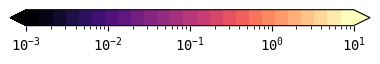

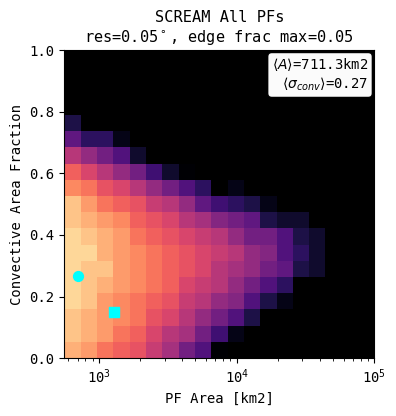

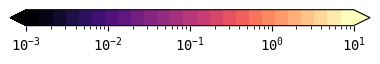

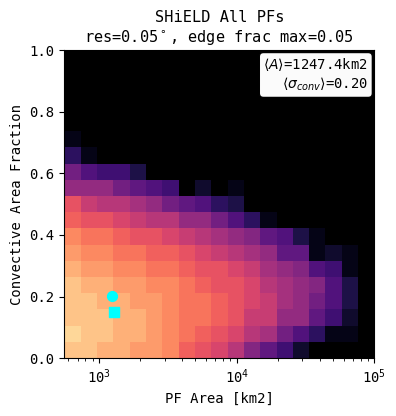

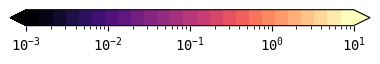

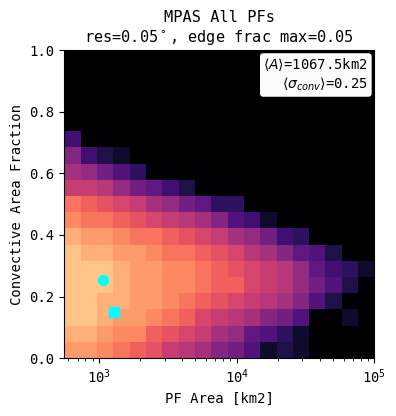

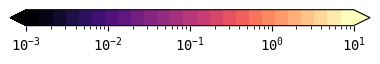

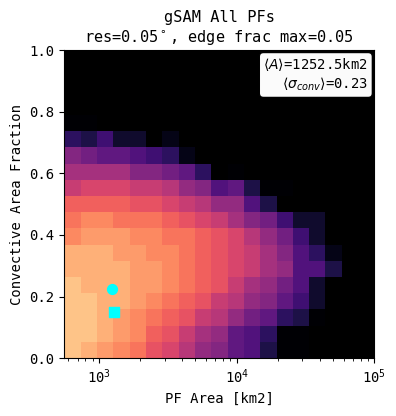

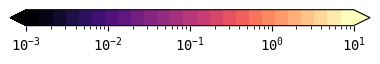

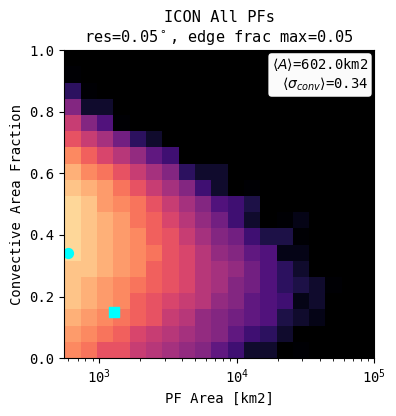

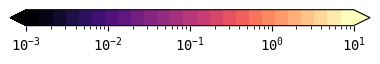

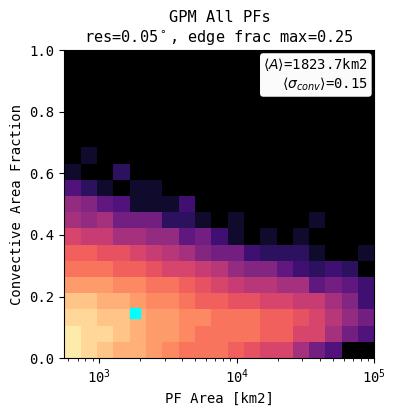

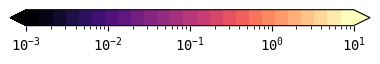

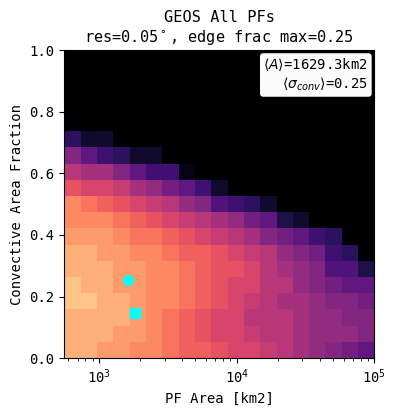

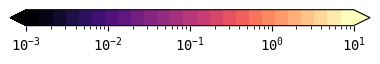

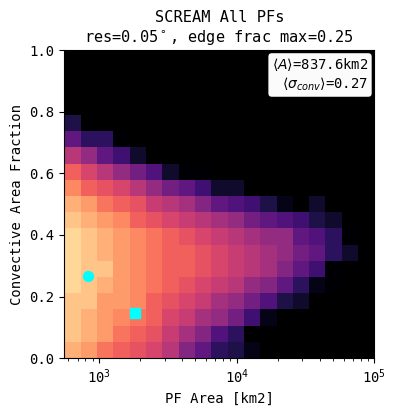

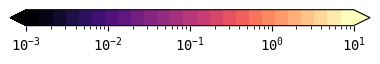

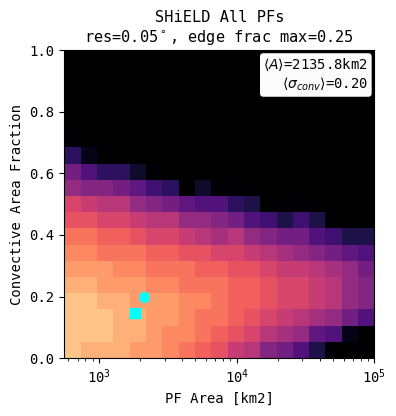

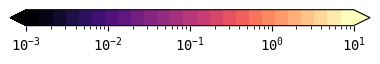

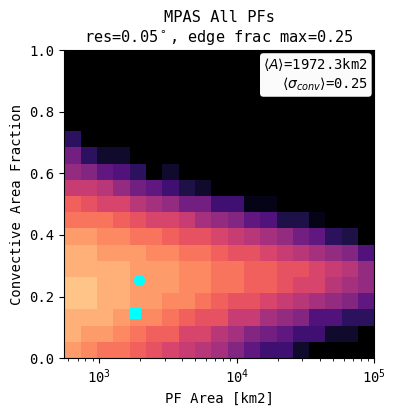

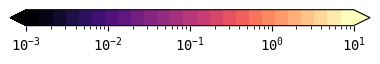

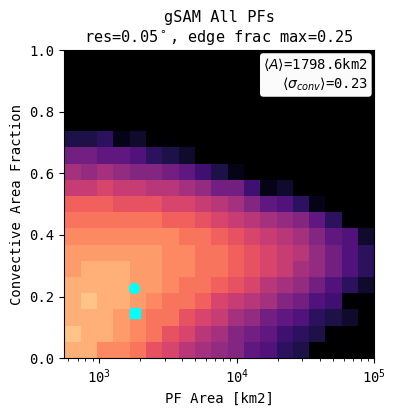

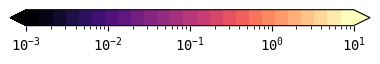

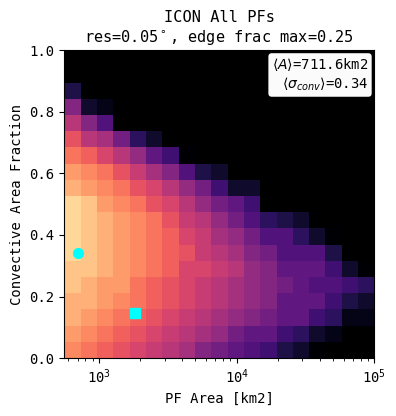

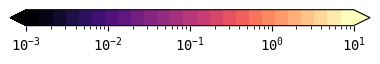

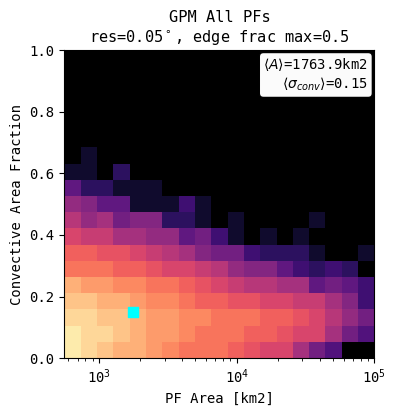

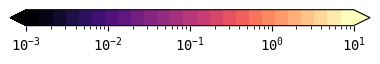

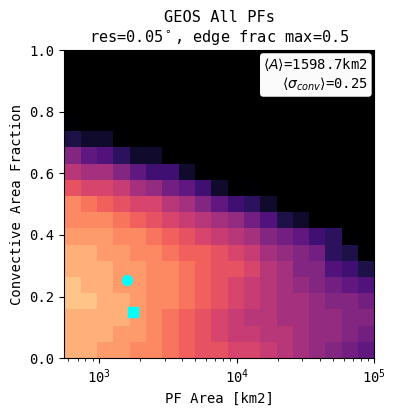

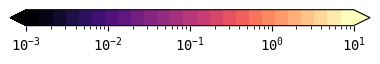

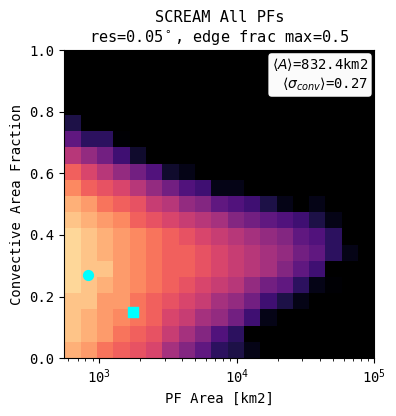

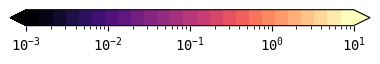

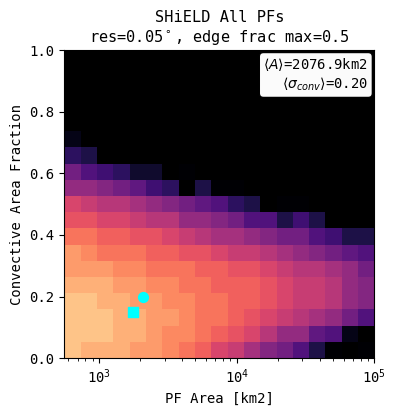

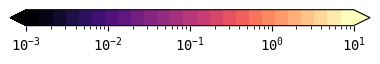

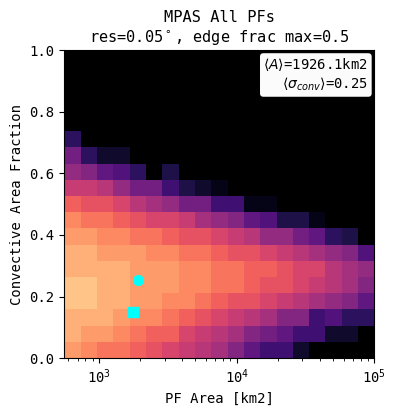

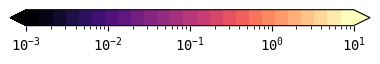

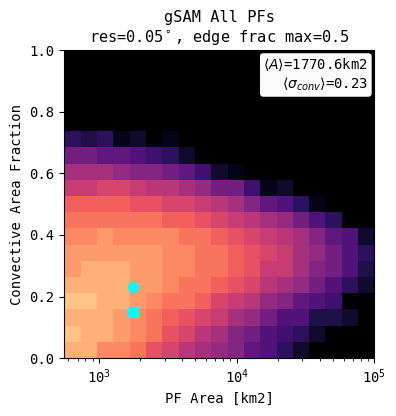

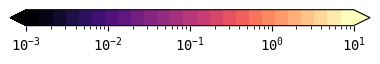

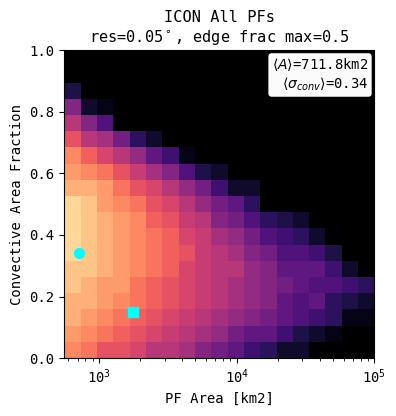

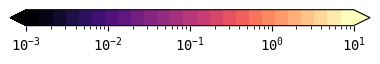

In [2]:
# Sweep parameters
_RES = "0p05"
_ACCUM = "15min"
edge_frac_max_list = [0.0, 0.05, 0.25, 0.5]

for _EDGE_FRAC_MAX in edge_frac_max_list:

    # Load features (IMERG is native 0.1 deg, so it takes no res argument)
    _MAX_PR_MIN = 10.0
    feature_stats_dict = {
        'GPM': load_gpm_feature_stats(threshold=1.0, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        # 'IMERG': load_imerg_feature_stats(threshold=1, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'GEOS': load_dyamond_feature_stats('GEOS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'MPAS': load_dyamond_feature_stats('MPAS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'gSAM': load_dyamond_feature_stats('gSAM-4km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    }
    # Set Plotting Parameters
    _RES_DEG = _RES.replace('p', '.')
    mean_color = 'cyan'
    obs_marker = 's'
    model_marker = 'o'
    x_bins = np.logspace(2.75, 5, 20)
    y_bins = np.linspace(0, 1, 20)
    cmap = discrete_cmap(plt.cm.magma, 25)
    norm = colors.LogNorm(vmin=1e-3, vmax=1e1)
    cmap.set_under('black')
    cmap.set_bad('black')

    # Plot PDF
    for source, df in feature_stats_dict.items():
    # Make the plot
        x_data = df['area_km2']
        y_data = df['px_ge_10mmhr'] / df['size_px']

        fig, ax, cbar_fig, cbar_ax, data = plot_mean_stat(
            x_data=x_data,
            y_data=y_data,
            x_bins=x_bins,
            y_bins=y_bins,
            data_to_bin=None,
            statistic='count',
            density=True,
            cmap=cmap,
            norm=norm,
            figsize=(4,4),
            return_data=True,
            return_colorbar_separate=True
        )

        # Add marker showing the average value
        def _plot_mean(ax, x_data, y_data, color, marker, label, legend=False, add_text=False):
            mean_x, mean_y = np.nanmean(x_data), np.nanmean(y_data)
            ax.scatter(mean_x, mean_y, label=label, color=color, marker=marker, s=50)
            if add_text:
                text = fr"$\langle A\rangle$={mean_x:.1f}km2" + "\n" + rf"$\langle\sigma_{{conv}}\rangle$={mean_y:.2f}"
                ax.text(
                    0.98, 0.98, text,
                    transform=ax.transAxes,
                    ha="right",
                    va="top",
                    fontsize=10,
                    bbox=dict(
                        boxstyle="round,pad=0.3",
                        facecolor="white",
                        alpha=0.99,
                        edgecolor="black",
                    ),
                )
            if legend:
                ax.legend(loc='upper left', fontsize=12)

        if source=="GPM":
            _plot_mean(ax, x_data, y_data, color=mean_color, marker=obs_marker, label=None, add_text=True)
            x_obs, y_obs = x_data, y_data
        else:
            _plot_mean(ax, x_data, y_data, color=mean_color, marker=model_marker, label='None', add_text=True)
            _plot_mean(ax, x_obs, y_obs, color=mean_color, marker=obs_marker, label='GPM', add_text=False)
        ax.set_title(
            f'{source} All PFs\n'
            fr'res={_RES_DEG}$^\circ$, edge frac max={_EDGE_FRAC_MAX}',
            fontsize=11,
        )
        ax.set_xscale('log')
        ax.set_xlabel('PF Area [km2]')
        ax.set_ylabel('Convective Area Fraction')

        save_figure(fig, f'AllPFs_A_CAF_PDF_{source}_EdgeFracMax{_EDGE_FRAC_MAX}_Res_{_RES_DEG}_Accum_{_ACCUM}.pdf')
        save_figure(cbar_fig, f'AllPFs_A_CAF_PDF_{source}_EdgeFracMax{_EDGE_FRAC_MAX}_Res_{_RES_DEG}_Accum_{_ACCUM}_colorbar.pdf')



# Plot PDF of Extreme Values

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_GPM_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_GPM_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_GEOS_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_GEOS_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_SCREAM_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_SCREAM_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_SHiELD_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_SHiELD_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_MPAS_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_MPAS_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_gSAM_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...


...

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_GEOS_EdgeFracMax0.5_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_SCREAM_EdgeFracMax0.5_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_SCREAM_EdgeFracMax0.5_Res_0.05_Accum_15min_colorbar.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_SHiELD_EdgeFracMax0.5_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_SHiELD_EdgeFracMax0.5_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_MPAS_EdgeFracMax0.5_Res_0.05_Accum_15min.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_MPAS_EdgeFracMax0.5_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_gSAM_EdgeFracMax0.5_Res_0.05_Accum_15min.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_gSAM_EdgeFracMax0.5_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_ICON_EdgeFracMax0.5_Res_0.05_Accum_15min.pdf as PDF ...


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_PDF_ICON_EdgeFracMax0.5_Res_0.05_Accum_15min_colorbar.pdf as PDF ...


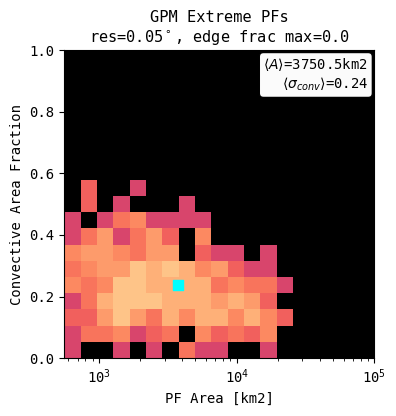

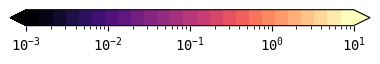

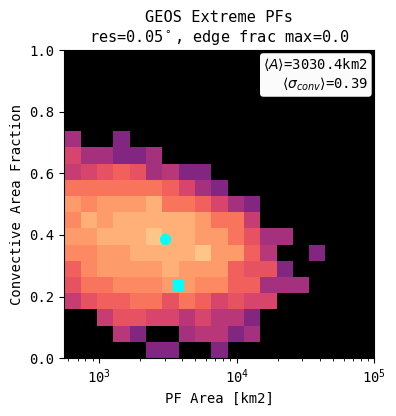

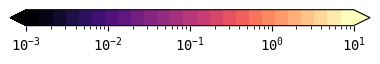

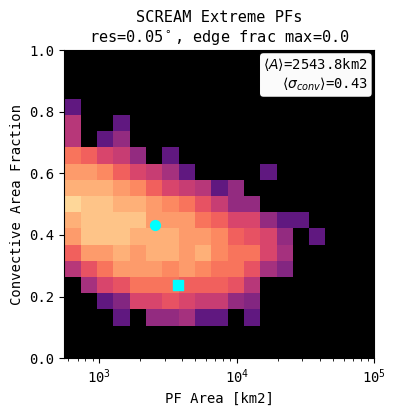

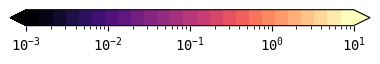

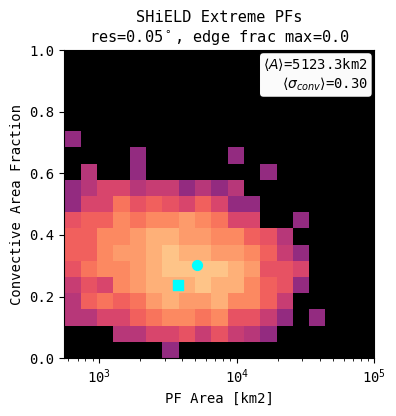

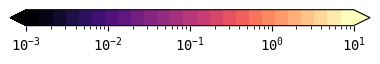

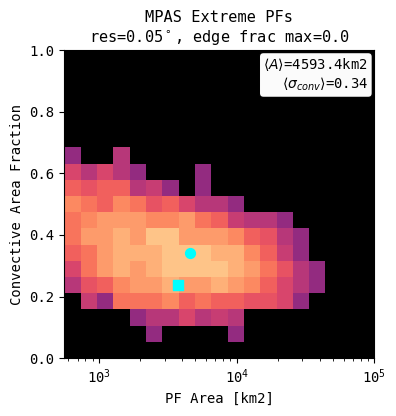

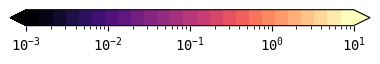

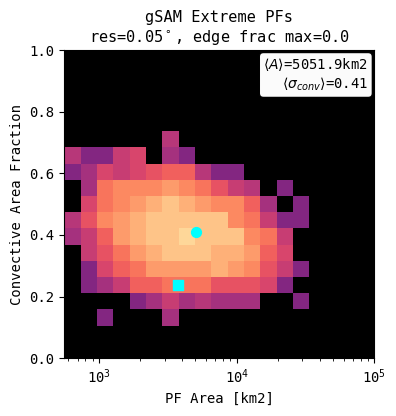

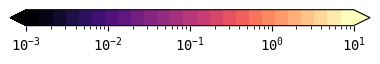

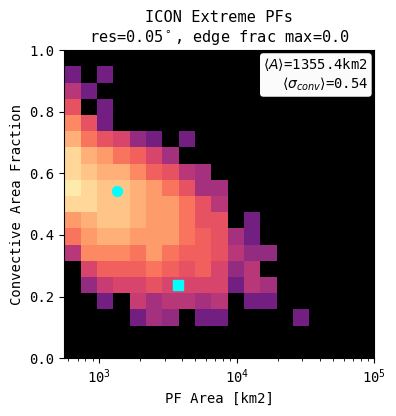

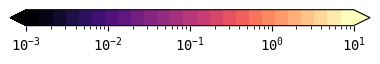

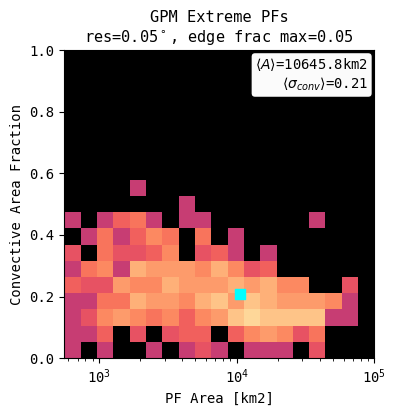

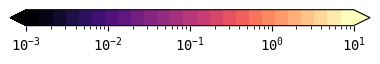

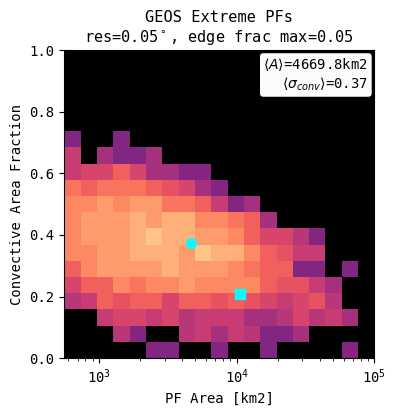

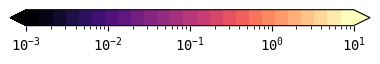

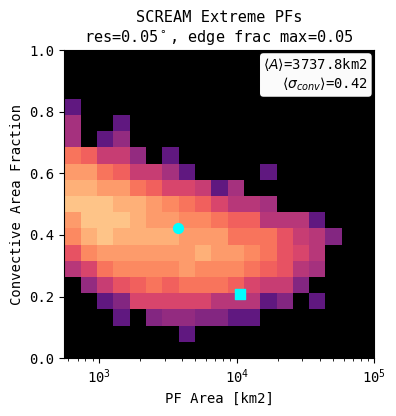

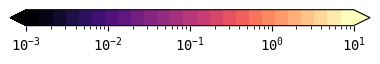

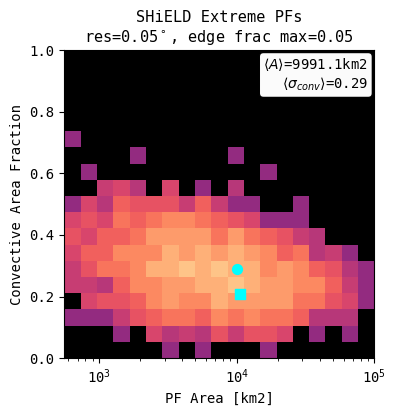

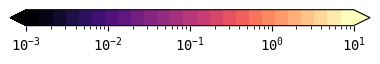

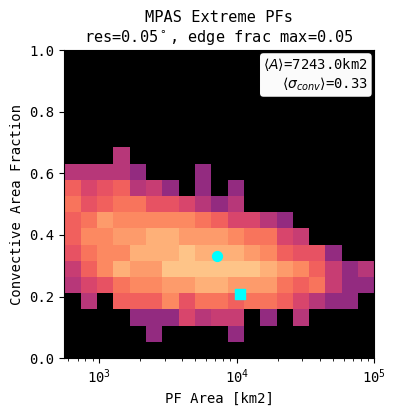

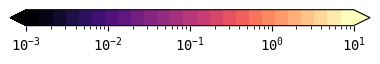

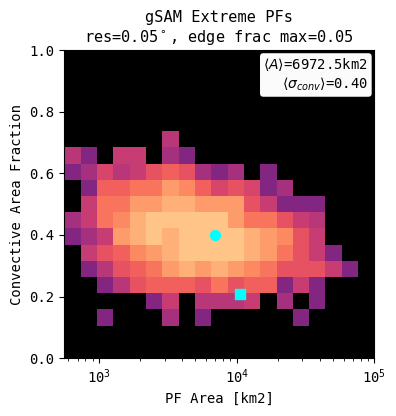

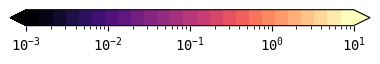

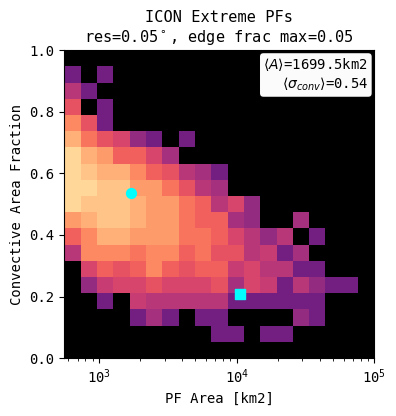

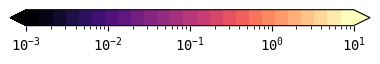

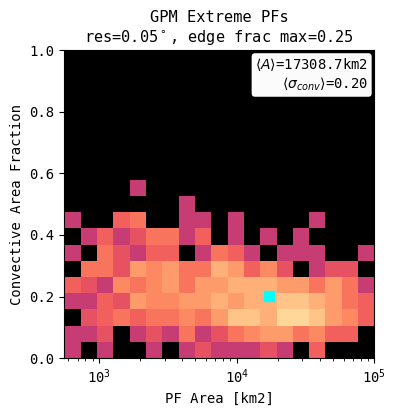

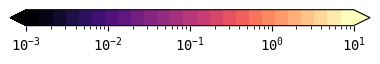

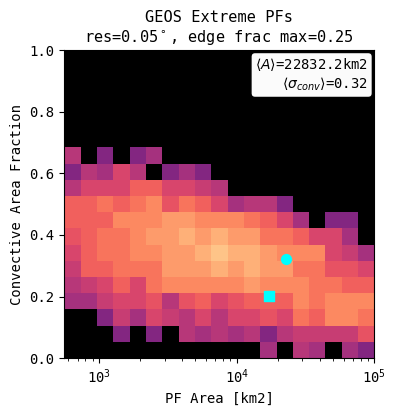

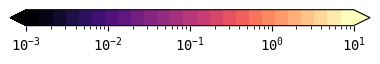

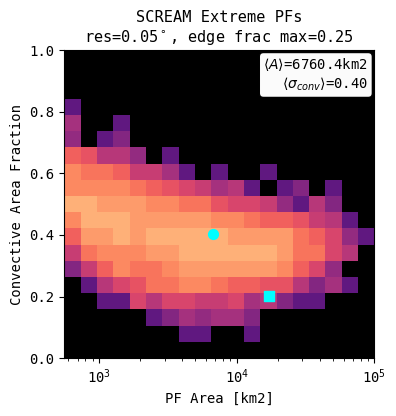

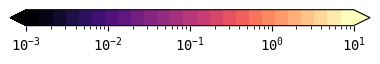

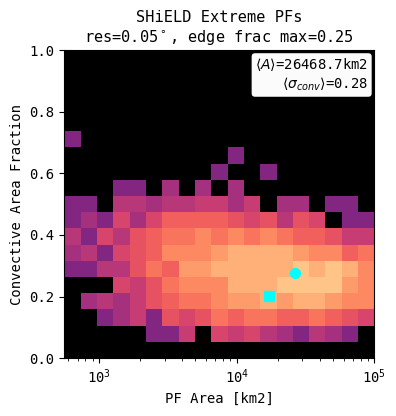

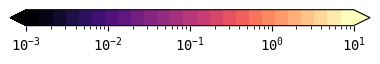

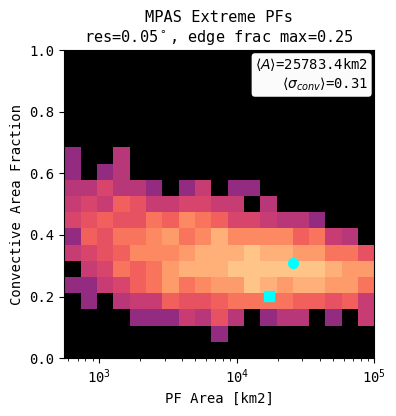

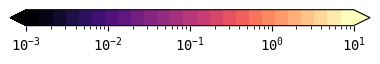

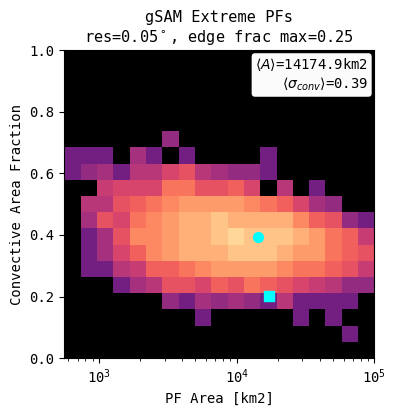

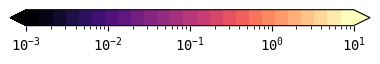

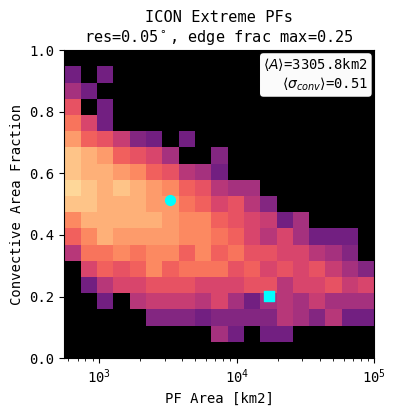

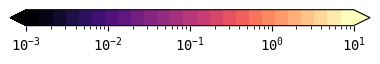

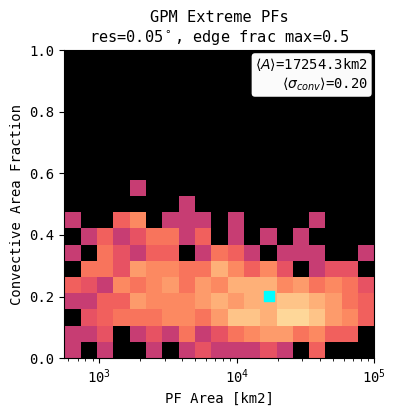

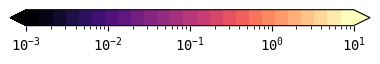

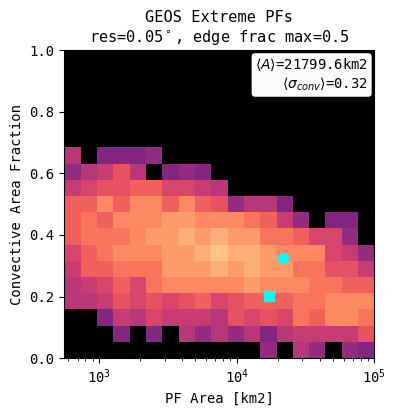

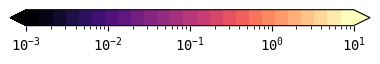

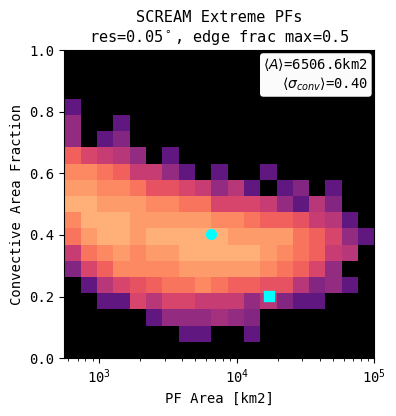

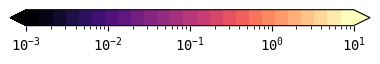

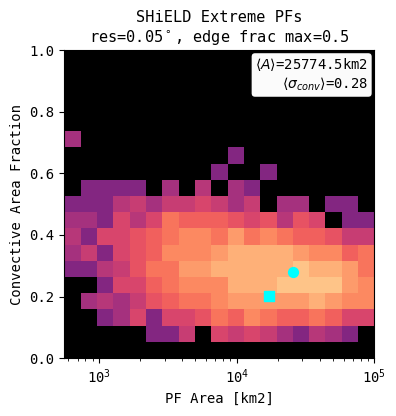

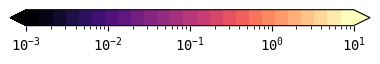

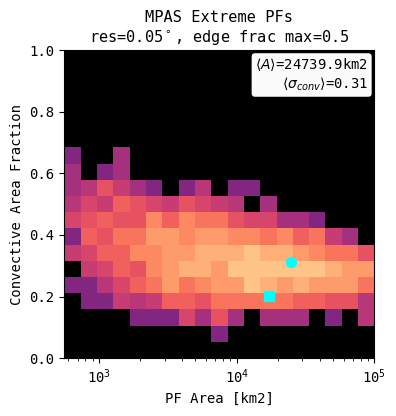

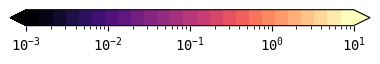

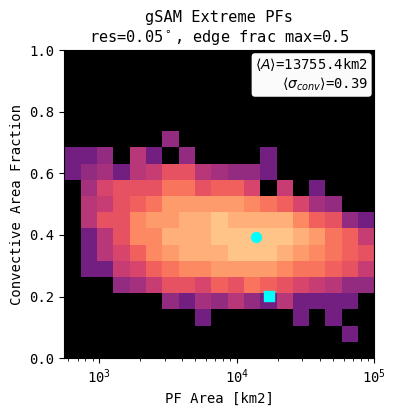

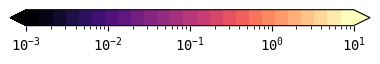

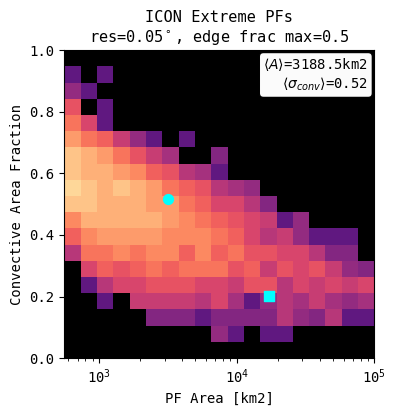

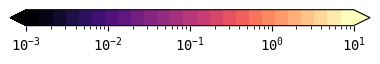

In [ ]:
# Sweep parameters
_RES = "0p05"
_ACCUM = "15min"
edge_frac_max_list = [0.0, 0.05, 0.25, 0.5]

for _EDGE_FRAC_MAX in edge_frac_max_list:

    # Load features (IMERG is native 0.1 deg, so it takes no res argument)
    _MAX_PR_MIN = 10.0
    feature_stats_dict = {
        'GPM': load_gpm_feature_stats(threshold=1.0, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        # 'IMERG': load_imerg_feature_stats(threshold=1, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'GEOS': load_dyamond_feature_stats('GEOS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'MPAS': load_dyamond_feature_stats('MPAS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'gSAM': load_dyamond_feature_stats('gSAM-4km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    }
    # Set Plotting Parameters
    _RES_DEG = _RES.replace('p', '.')
    mean_color = 'cyan'
    obs_marker = 's'
    model_marker = 'o'
    x_bins = np.logspace(2.75, 5, 20)
    y_bins = np.linspace(0, 1, 20)
    cmap = discrete_cmap(plt.cm.magma, 25)
    norm = colors.LogNorm(vmin=1e-3, vmax=1e1)
    cmap.set_under('black')
    cmap.set_bad('black')

    # Plot PDF
    for source, df in feature_stats_dict.items():
        # Restrict data to only extremes
        thresh = df['max_precip_mm_hr'].quantile(0.99)
        df = df.filter(
            pl.col("max_precip_mm_hr") >= thresh
        )

        # Make the plot
        x_data = df['area_km2']
        y_data = df['px_ge_10mmhr'] / df['size_px']

        fig, ax, cbar_fig, cbar_ax, data = plot_mean_stat(
            x_data=x_data,
            y_data=y_data,
            x_bins=x_bins,
            y_bins=y_bins,
            data_to_bin=None,
            statistic='count',
            density=True,
            cmap=cmap,
            norm=norm,
            figsize=(4,4),
            return_data=True,
            return_colorbar_separate=True
        )

        # Add marker showing the average value
        def _plot_mean(ax, x_data, y_data, color, marker, label, legend=False, add_text=False):
            mean_x, mean_y = np.nanmean(x_data), np.nanmean(y_data)
            ax.scatter(mean_x, mean_y, label=label, color=color, marker=marker, s=50)
            if add_text:
                text = fr"$\langle A\rangle$={mean_x:.1f}km2" + "\n" + rf"$\langle\sigma_{{conv}}\rangle$={mean_y:.2f}"
                ax.text(
                    0.98, 0.98, text,
                    transform=ax.transAxes,
                    ha="right",
                    va="top",
                    fontsize=10,
                    bbox=dict(
                        boxstyle="round,pad=0.3",
                        facecolor="white",
                        alpha=0.99,
                        edgecolor="black",
                    ),
                )
            if legend:
                ax.legend(loc='upper left', fontsize=12)

        if source=="GPM":
            _plot_mean(ax, x_data, y_data, color=mean_color, marker=obs_marker, label=None, add_text=True)
            x_obs, y_obs = x_data, y_data
        else:
            _plot_mean(ax, x_data, y_data, color=mean_color, marker=model_marker, label='None', add_text=True)
            _plot_mean(ax, x_obs, y_obs, color=mean_color, marker=obs_marker, label='GPM', add_text=False)
        ax.set_title(
            f'{source} Extreme PFs\n'
            fr'res={_RES_DEG}$^\circ$, edge frac max={_EDGE_FRAC_MAX}',
            fontsize=11,
        )
        ax.set_xscale('log')
        ax.set_xlabel('PF Area [km2]')
        ax.set_ylabel('Convective Area Fraction')


        save_figure(fig, f'ExPFs_A_CAF_PDF_{source}_EdgeFracMax{_EDGE_FRAC_MAX}_Res_{_RES_DEG}_Accum_{_ACCUM}.pdf')
        save_figure(cbar_fig, f'ExPFs_A_CAF_PDF_{source}_EdgeFracMax{_EDGE_FRAC_MAX}_Res_{_RES_DEG}_Accum_{_ACCUM}_colorbar.pdf')


# Regressing MaxPr onto Concentration via Total Least Squares

In [ ]:
# Slope of log MaxPr against the concentration rho, fitted by total least squares in the
# same (area, CAF) bins the DeltaMaxPr sweep below uses. Binning on area and convective
# area fraction is what makes the slope interpretable: it is the concentration effect at
# fixed size and fixed convective coverage, not a re-reading of the size-intensity
# relationship.
#
# The fit is on log MaxPr, so the slope is a fractional sensitivity, reported as
# 100 * (exp(b) - 1) = the % change in MaxPr per unit rho. That puts it in the same units
# as the DeltaMaxPr maps instead of a separate quantity in mm/hr, and pulls the skewed
# MaxPr distribution towards the normality the p-value assumes.
#
# Three fits are run per source, because "total least squares" is not one thing here and
# the choice matters more than anything else in this cell:
#
#   OLS           no correction. Attenuated towards zero by the measurement error in rho,
#                 so it is a lower bound on the sensitivity.
#   Attenuation   the headline. Method of moments, b = b_ols / reliability, where
#                 reliability = 1 - sigma_rho^2 / s_xx is the share of rho's spread in the
#                 bin that is real. It undoes exactly the bias that noise in rho causes and
#                 nothing else, and it needs no assumed numbers: rho is a ratio of pixel
#                 counts, so sigma_rho = sqrt(rho (1 - rho) / n_conv), floored at the
#                 1/n_conv quantisation of rho itself.
#   RMA           standardise both axes, then fit orthogonally. This is TLS in the usual
#                 unit-free sense, but its slope is b_ols / |r|, so it corrects for ALL the
#                 scatter in log MaxPr rather than only the measurement part. MaxPr varies
#                 at fixed (area, CAF, rho) for real physical reasons too, and that spread
#                 must not be corrected away. With |r| ~ 0.1-0.2 in these bins RMA inflates
#                 the slope five- to tenfold, so it is an upper bound, not an estimate.
#
# _N_CONV_MIN is the other thing that matters. The median GPM feature has TWO convective
# pixels, so its rho is either 0.5 or 1 and carries about one bit; across the full sample
# the estimated error in rho is a large fraction of rho's spread and no errors-in-variables
# correction is identifiable. Requiring enough convective pixels for rho to be resolved
# costs most of the features but is what makes the slope mean anything. The cell below
# sweeps the cut so the cost is visible.

_RES = "0p05"
_ACCUM = "15min"
_MAX_PR_MIN = 10.0
_MAX_PR_MAX = SATURATED_MAXPR_MIN   # drop the censored 300 mm/hr features (obs and models)
_N_CONV_MIN = 10                    # convective pixels needed for rho to be resolved
_MIN_RELIABILITY = 0.1              # min share of rho's spread that must be real signal
_TLS_SAMP_MIN = 11                  # bin-level minimum, as in the DeltaMaxPr sweep
_TLS_MIN_OFF_MODE = 5               # features off the modal rho needed to define a slope
_TLS_VMAX = 200                     # colour limit, % per unit rho
X_BINS = np.logspace(2.5, 4.5, 20)
Y_BINS = np.linspace(0, 1, 20)
edge_frac_max_list = [0.0, 0.05, 0.25, 0.5, 0.75, 1.0]


def _months(df):
    """Months present in a feature table; handles both ISO strings and yyyymmdd floats."""
    return set(
        df["time"].cast(pl.Utf8).str.extract(r"^\d{4}-?(\d{2})", 1).drop_nulls().unique().to_list()
    )


def _tls_fields(df, n_conv_min=None):
    """rho, its counting error, MaxPr, area and CAF, for features with rho resolved.

    Returns plain numpy arrays, already cut to `n_conv_min` convective pixels, plus the
    fraction of the input that survived the cut.
    """
    n_conv_min = _N_CONV_MIN if n_conv_min is None else n_conv_min
    n_conv = df['px_ge_10mmhr'].to_numpy().astype(float)
    rho = (df['largest_core_10mmhr_px'] / df['px_ge_10mmhr']).to_numpy().astype(float)
    # rho = k / n_conv is a ratio of counts, so its error is the binomial one -- except
    # that this vanishes at rho = 1, where most features sit. One convective pixel moving
    # in or out of the largest core changes rho by 1/n_conv, so that quantisation is the
    # floor below which the error cannot fall.
    with np.errstate(invalid='ignore', divide='ignore'):
        rho_err = np.maximum(np.sqrt(rho * (1 - rho) / n_conv), 1.0 / n_conv)
    maxpr = df['max_precip_mm_hr'].to_numpy().astype(float)
    area = (df['size_px'] * gpm_area_factor()).to_numpy().astype(float)
    caf = (df['px_ge_10mmhr'] / df['size_px']).to_numpy().astype(float)
    keep = n_conv >= n_conv_min
    return (rho[keep], rho_err[keep], maxpr[keep], area[keep], caf[keep],
            float(keep.mean()))


def _wtd_sig_mean(grid, p, counts, alpha=0.05):
    """Count-weighted mean of a grid over the bins that pass the significance cut."""
    keep = (p <= alpha) & np.isfinite(grid) & np.isfinite(counts)
    return float(np.average(grid[keep], weights=counts[keep])) if keep.any() else np.nan


def _tls_fit(rho, rho_err, maxpr, area, caf, scaling, **kw):
    """A BinnedTLSSlope on the standard settings, varying only the estimator."""
    return BinnedTLSSlope(
        predictor=rho,
        response=maxpr,
        x_data=area,
        y_data=caf,
        x_bins=X_BINS,
        y_bins=Y_BINS,
        log_response=True,
        percent=True,
        scaling=scaling,
        # Passed to every fit, not just the corrected one, so all three are defined on
        # the same set of bins and can be compared bin by bin.
        predictor_err=rho_err,
        min_reliability=_MIN_RELIABILITY,
        samp_min=_TLS_SAMP_MIN,
        min_off_mode=_TLS_MIN_OFF_MODE,
        **kw,
    )


tls_slope_summaries = {}

for _EDGE_FRAC_MAX in edge_frac_max_list:

    # Load features (IMERG is native 0.1 deg, so it takes no res argument)
    feature_stats_dict = {
        'GPM': load_gpm_feature_stats(threshold=1.0, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        # 'IMERG': load_imerg_feature_stats(threshold=1, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'GEOS': load_dyamond_feature_stats('GEOS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'MPAS': load_dyamond_feature_stats('MPAS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'gSAM': load_dyamond_feature_stats('gSAM-4km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
    }

    # Hold the sampling period fixed: comparing months would compare climatologies.
    months = {name: _months(df) for name, df in feature_stats_dict.items()}
    assert len(set(map(frozenset, months.values()))) == 1, f"Sources cover different months: {months}"
    print(f"edge_frac_max={_EDGE_FRAC_MAX}: all sources cover month(s) {sorted(next(iter(months.values())))}")

    for model_name, df in feature_stats_dict.items():
        rho, rho_err, maxpr, area, caf, kept_frac = _tls_fields(df)

        # The headline: OLS un-attenuated by the measured error in rho. ols_grid comes
        # back from the same object, so the uncorrected slope needs no second fit.
        att = _tls_fit(rho, rho_err, maxpr, area, caf, 'attenuation')
        fig, ax, s, wtd_sig_mean, p, counts = att.plot(
            xlabel='PF Area [km²]',
            ylabel='Conv. Area Fraction',
            title=f'{model_name} $d\\,$MaxPr$/d\\rho$ [%]\nEdgeFracMax{_EDGE_FRAC_MAX}, nconv$\\geq${_N_CONV_MIN}',
            cmap=discrete_cmap(plt.cm.coolwarm, 25),
            norm=colors.TwoSlopeNorm(vmin=-_TLS_VMAX, vcenter=0, vmax=_TLS_VMAX),
            return_p=True,
            return_counts=True,
        )
        save_figure(fig, f'TLSSlope_{model_name}_EdgeFracMax{_EDGE_FRAC_MAX}_NConvMin{_N_CONV_MIN}.pdf')

        # The unit-free TLS the advisor asked for, kept as the upper bound.
        rma = _tls_fit(rho, rho_err, maxpr, area, caf, 'standardize')
        s_rma, p_rma, counts_rma = rma.compute()

        summary = BinnedTLSSlope.summarise(s, p, counts)
        summary.update({
            'kept_frac': kept_frac,
            'ols_wtd_sig_mean': _wtd_sig_mean(att.ols_grid, p, counts),        # lower bound
            'attenuation_wtd_sig_mean': wtd_sig_mean,                          # the estimate
            'rma_wtd_sig_mean': BinnedTLSSlope.summarise(s_rma, p_rma, counts_rma)['count_weighted_sig_mean'],
            'median_abs_r': float(np.nanmedian(np.abs(att.r_grid))),
            'median_reliability': float(np.nanmedian(att.reliability_grid)),
            'median_tie_frac': float(np.nanmedian(att.tie_frac_grid)),
            # Bins lost to the reliability guard: rho too coarsely measured there for the
            # correction to be identifiable at all.
            'unidentifiable_bins': int(np.sum(np.isfinite(att.reliability_grid)
                                              & (att.reliability_grid <= _MIN_RELIABILITY))),
        })
        tls_slope_summaries[(_EDGE_FRAC_MAX, model_name)] = summary

        print(
            f"    {model_name:7s} OLS {summary['ols_wtd_sig_mean']:7.1f}%  "
            f"corrected {summary['attenuation_wtd_sig_mean']:7.1f}%  "
            f"RMA {summary['rma_wtd_sig_mean']:8.1f}%  |  "
            f"kept {kept_frac:5.1%} of features, "
            f"{summary['sig_bins']:3d}/{summary['filled_bins']:3d} bins significant, "
            f"median |r| {summary['median_abs_r']:.2f}, "
            f"reliability {summary['median_reliability']:.2f}"
        )

In [ ]:
# Summary of the TLS sweep: the headline table, the sensitivity of the headline to the
# edge-fraction cut, how much of the answer is the choice of estimator, and how much is
# the convective-pixel cut that makes rho resolvable at all. Reads tls_slope_summaries
# and feature_stats_dict, so the cell above has to have run first.

# --- headline table --------------------------------------------------------------
tls_slope_table = pl.DataFrame([
    {
        "edge_frac_max": edge,
        "source": name,
        "n_features": int(d["n_features"]),
        "kept_frac": round(d["kept_frac"], 3),
        "sig_bins": d["sig_bins"],
        "filled_bins": d["filled_bins"],
        "OLS [%/rho]": round(d["ols_wtd_sig_mean"], 1),
        "corrected [%/rho]": round(d["attenuation_wtd_sig_mean"], 1),
        "RMA [%/rho]": round(d["rma_wtd_sig_mean"], 1),
        "median |r|": round(d["median_abs_r"], 3),
        "median reliability": round(d["median_reliability"], 2),
        "median tie frac": round(d["median_tie_frac"], 2),
    }
    for (edge, name), d in tls_slope_summaries.items()
])
print(tls_slope_table)
save_table(tls_slope_table, f'TLSSlope_summary_NConvMin{_N_CONV_MIN}.csv')

_sources = list(dict.fromkeys(name for _, name in tls_slope_summaries))
_edges = sorted({edge for edge, _ in tls_slope_summaries})
_x = np.arange(len(_edges))  # evenly spaced: the cuts are a sweep, not a continuous axis
_models = [n for n in _sources if n != "GPM"]
_model_colors = dict(zip(_models, plt.cm.viridis(np.linspace(0, 0.9, max(len(_models), 1)))))
_color = lambda n: "k" if n == "GPM" else _model_colors[n]
_style = lambda n: dict(color=_color(n), lw=2.5 if n == "GPM" else 1.5,
                        ms=6 if n == "GPM" else 4, zorder=3 if n == "GPM" else 2)

# --- sensitivity to the edge-fraction cut ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)
for ax, key, label in zip(
    axes,
    ["attenuation_wtd_sig_mean", "rma_wtd_sig_mean"],
    ["Corrected for the error in $\\rho$", "RMA (upper bound)"],
):
    for name in _sources:
        y = [tls_slope_summaries.get((edge, name), {}).get(key, np.nan) for edge in _edges]
        ax.plot(_x, y, "o-", label=name, **_style(name))
    ax.axhline(0, color="0.6", lw=0.8, zorder=0)
    ax.set_xticks(_x)
    ax.set_xticklabels([f"{e:g}" for e in _edges])
    ax.set_xlabel("edge_frac_max")
    ax.set_title(label)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("$d\\,$MaxPr$/d\\rho$ [%]\ncount-weighted over significant bins")
axes[0].legend(fontsize=7, ncol=2, frameon=False)
fig.suptitle(f"Sensitivity of the concentration slope to the edge-fraction cut "
             f"(nconv$\\geq${_N_CONV_MIN})", y=1.02)
fig.tight_layout()
save_figure(fig, f"TLSSlope_vs_EdgeFracMax_NConvMin{_N_CONV_MIN}.pdf")

# --- how much of the answer is the choice of estimator ---------------------------
# All three fit the same points in the same bins and differ only in what they treat as
# noise, so the spread between them is the methodological uncertainty, not sampling
# uncertainty. If RMA sits far above the corrected slope, that gap is scatter in MaxPr
# being read as measurement error.
_CUT = _edges[0]
fig, ax = plt.subplots(figsize=(7.5, 4))
_xs = np.arange(len(_sources))
for i, name in enumerate(_sources):
    d = tls_slope_summaries[(_CUT, name)]
    lo, hi = d["ols_wtd_sig_mean"], d["rma_wtd_sig_mean"]
    ax.vlines(i, min(lo, hi), max(lo, hi), color="0.85", lw=8, zorder=1)
    ax.plot(i, d["ols_wtd_sig_mean"], "v", ms=8, color="0.45", mec="k", mew=0.5, zorder=2,
            label="OLS (attenuated, lower bound)" if i == 0 else None)
    ax.plot(i, d["attenuation_wtd_sig_mean"], "D", ms=8, color="#4c72b0", mec="k", mew=0.5, zorder=4,
            label="corrected for $\\sigma_\\rho$ (estimate)" if i == 0 else None)
    ax.plot(i, d["rma_wtd_sig_mean"], "^", ms=8, color="#c44e52", mec="k", mew=0.5, zorder=3,
            label="RMA (upper bound)" if i == 0 else None)
ax.axhline(0, color="0.6", lw=0.8, zorder=0)
ax.set_xticks(_xs)
ax.set_xticklabels(_sources, rotation=45, ha="right")
ax.set_yscale("symlog", linthresh=100)
ax.set_ylabel("$d\\,$MaxPr$/d\\rho$ [%]")
ax.set_title(f"How much of the slope is the choice of estimator\n"
             f"(edge_frac_max={_CUT:g}, nconv$\\geq${_N_CONV_MIN}; note symlog axis)")
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
save_figure(fig, f"TLSSlope_EstimatorComparison_EdgeFracMax{_CUT}.pdf")

# --- sensitivity to the convective-pixel cut -------------------------------------
# rho = largest_core / n_conv is quantised at 1/n_conv, so a feature with two convective
# pixels carries about one bit of rho. Raising the cut buys resolution in rho at the cost
# of sample size and of restricting the analysis to the largest convective features --
# that trade-off is a real limit on the method, not a tuning knob. Runs on whatever
# edge-fraction cut feature_stats_dict was left at by the sweep above.
_NCONV_SWEEP = [1, 3, 5, 10, 20, 50]
print(f"\nSensitivity to the convective-pixel cut, at edge_frac_max={_EDGE_FRAC_MAX:g}:")

tls_nconv_sensitivity = {}
for model_name, df in feature_stats_dict.items():
    rows = []
    for n_min in _NCONV_SWEEP:
        rho, rho_err, maxpr, area, caf, kept = _tls_fields(df, n_conv_min=n_min)
        o = _tls_fit(rho, rho_err, maxpr, area, caf, 'attenuation')
        s_n, p_n, c_n = o.compute()
        rows.append({
            "n_conv_min": n_min,
            "kept_frac": kept,
            "slope": BinnedTLSSlope.summarise(s_n, p_n, c_n)["count_weighted_sig_mean"],
            "ols": _wtd_sig_mean(o.ols_grid, p_n, c_n),
            "reliability": float(np.nanmedian(o.reliability_grid)),
            "sig_bins": int(((p_n <= 0.05) & ~np.isnan(s_n)).sum()),
        })
    tls_nconv_sensitivity[model_name] = rows

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)
for name in _sources:
    rows = tls_nconv_sensitivity[name]
    axes[0].plot(_NCONV_SWEEP, [r["slope"] for r in rows], "o-", label=name, **_style(name))
    axes[1].plot(_NCONV_SWEEP, [r["reliability"] for r in rows], "o-", **_style(name))
    axes[2].plot(_NCONV_SWEEP, [100 * r["kept_frac"] for r in rows], "o-", **_style(name))
for ax, ylabel, title in zip(
    axes,
    ["corrected $d\\,$MaxPr$/d\\rho$ [%]", "median reliability", "% of features kept"],
    ["The slope", "Is the correction identifiable?", "What it costs"],
):
    ax.set_xscale("log")
    ax.set_xticks(_NCONV_SWEEP)
    ax.set_xticklabels([str(n) for n in _NCONV_SWEEP])
    ax.set_xlabel("min convective pixels per feature")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
axes[0].axhline(0, color="0.6", lw=0.8, zorder=0)
axes[0].legend(fontsize=7, ncol=2, frameon=False)
axes[1].axhline(_MIN_RELIABILITY, color="0.5", ls=":", lw=1)
axes[2].set_yscale("log")
fig.suptitle(f"Resolving $\\rho$ costs sample size (edge_frac_max={_EDGE_FRAC_MAX:g})", y=1.02)
fig.tight_layout()
save_figure(fig, f"TLSSlope_vs_NConvMin_EdgeFracMax{_EDGE_FRAC_MAX}.pdf")

tls_nconv_table = pl.DataFrame([
    {"source": name, "n_conv_min": r["n_conv_min"], "kept_frac": round(r["kept_frac"], 4),
     "OLS [%/rho]": round(r["ols"], 1), "corrected [%/rho]": round(r["slope"], 1),
     "median reliability": round(r["reliability"], 2), "sig_bins": r["sig_bins"]}
    for name, rows in tls_nconv_sensitivity.items() for r in rows
])
print(tls_nconv_table)
save_table(tls_nconv_table, f'TLSSlope_NConvSweep_EdgeFracMax{_EDGE_FRAC_MAX}.csv')

# Plot concentration in Area CAF space

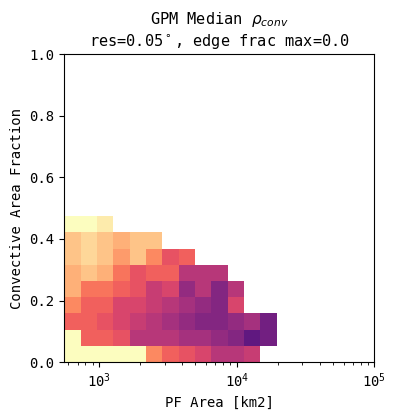

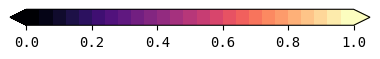

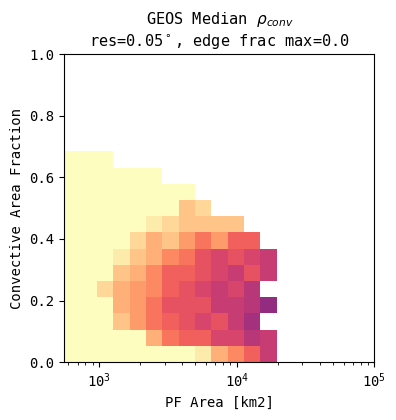

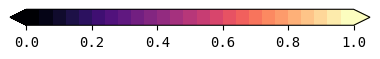

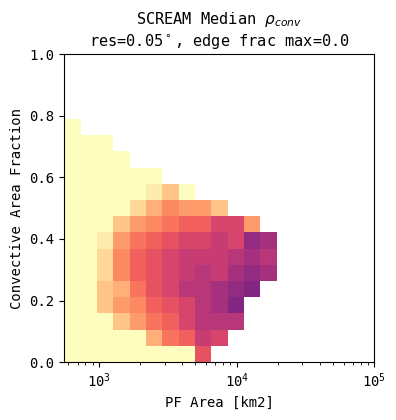

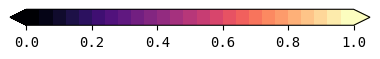

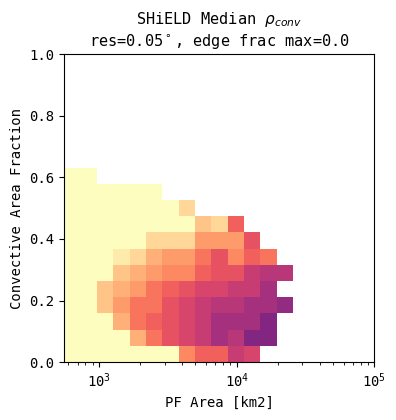

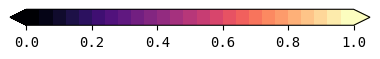

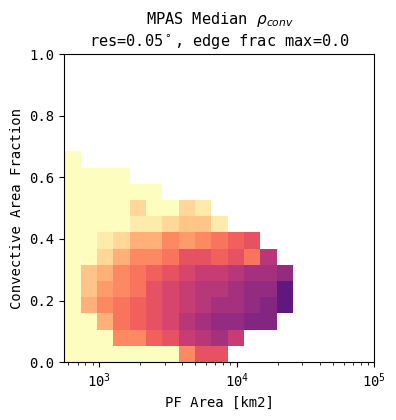

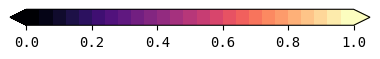

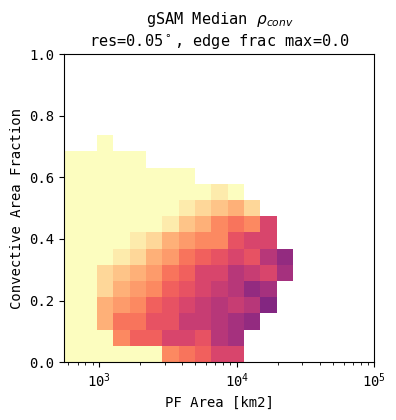

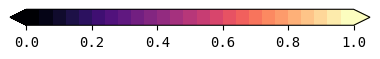

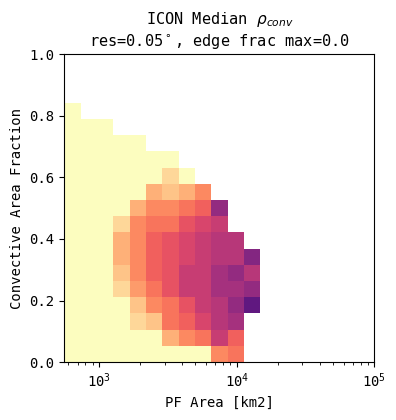

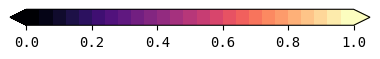

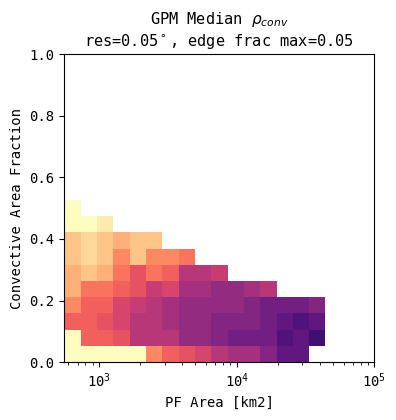

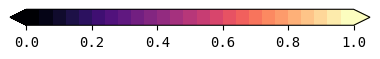

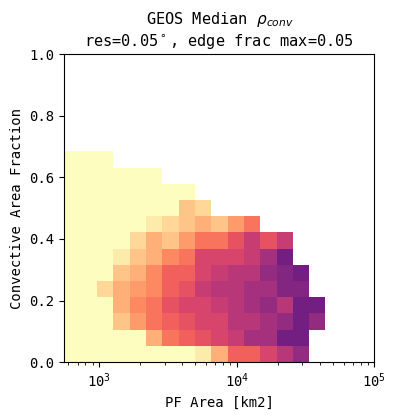

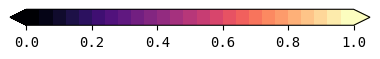

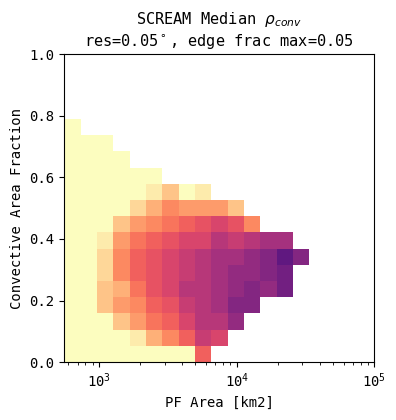

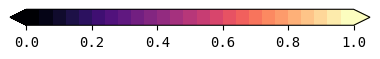

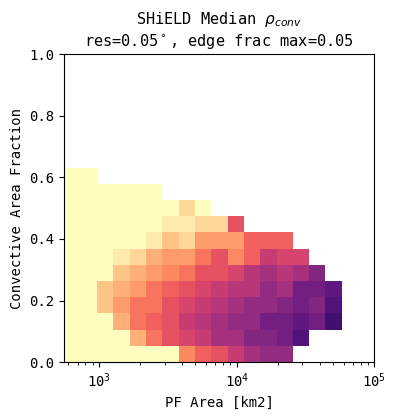

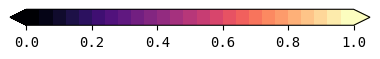

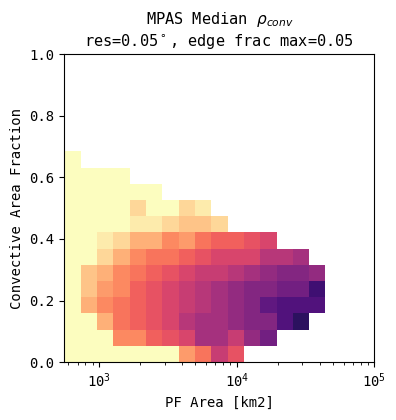

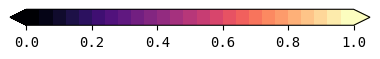

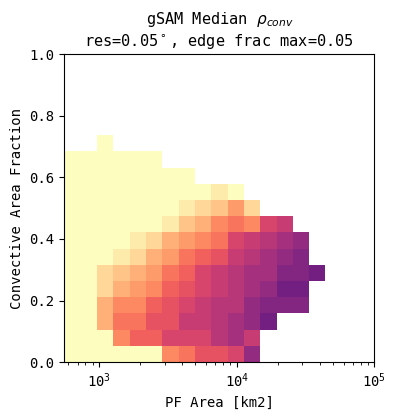

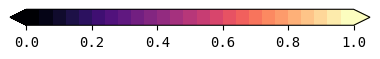

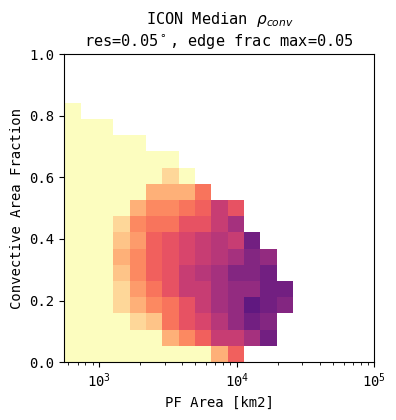

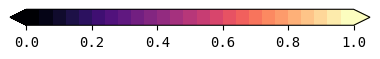

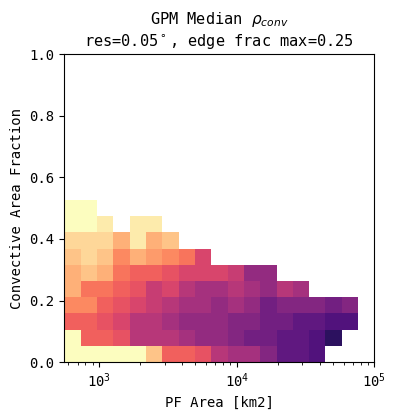

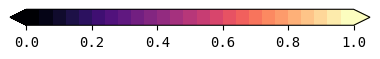

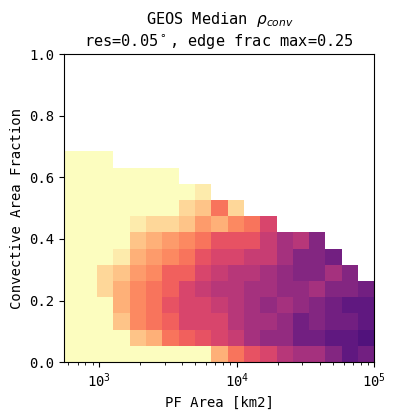

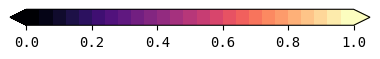

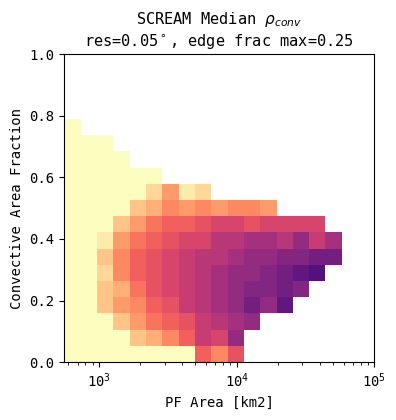

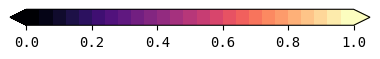

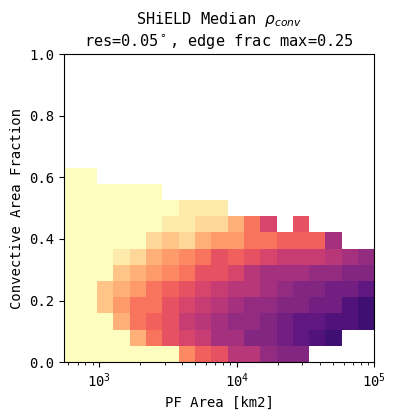

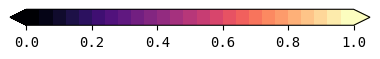

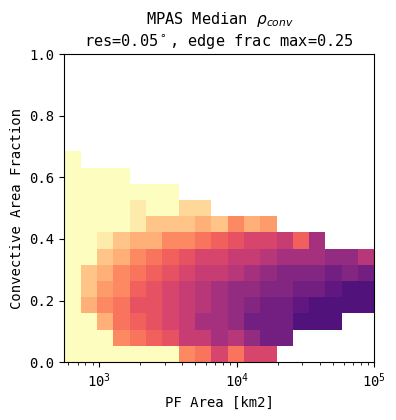

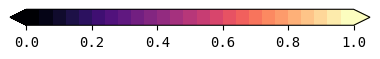

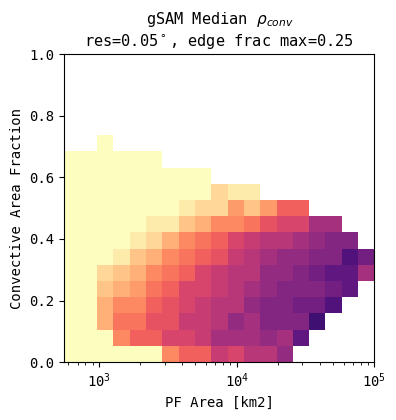

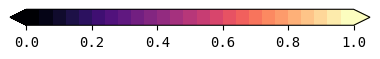

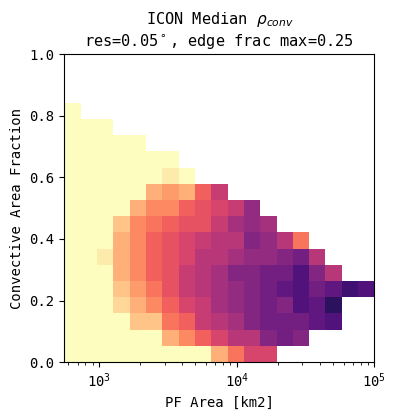

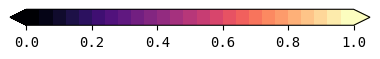

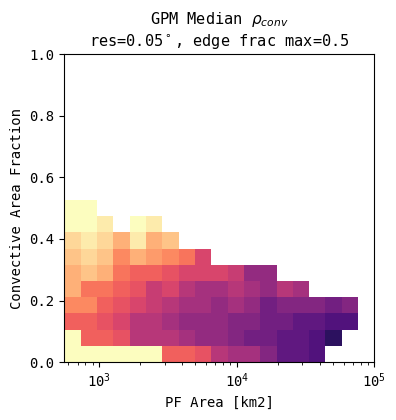

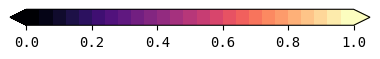

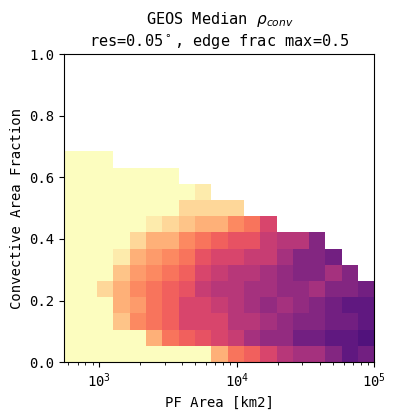

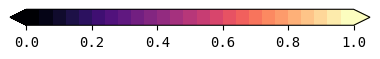

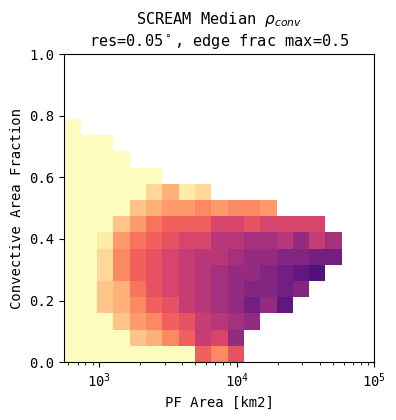

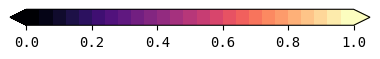

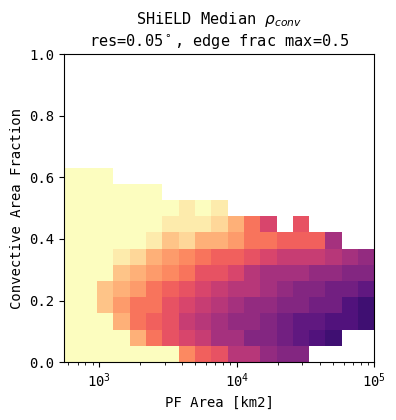

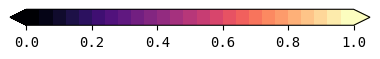

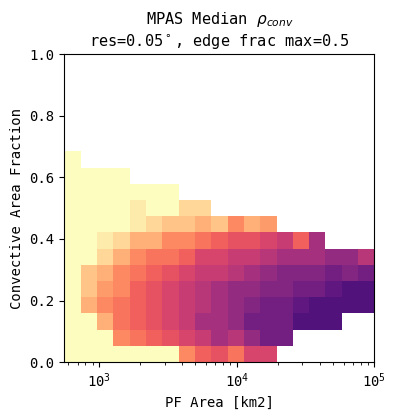

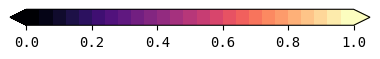

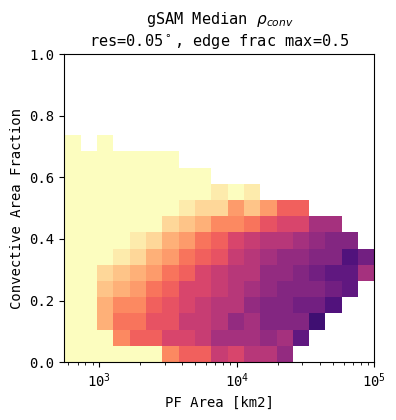

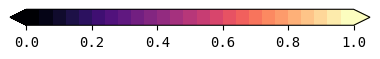

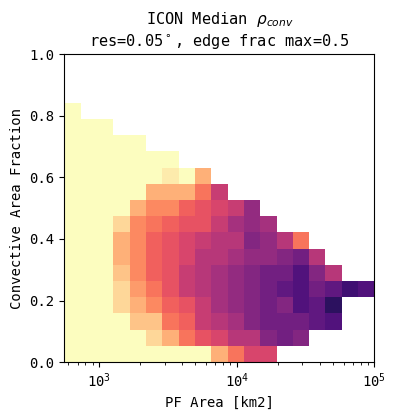

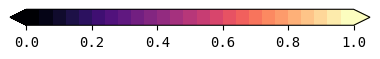

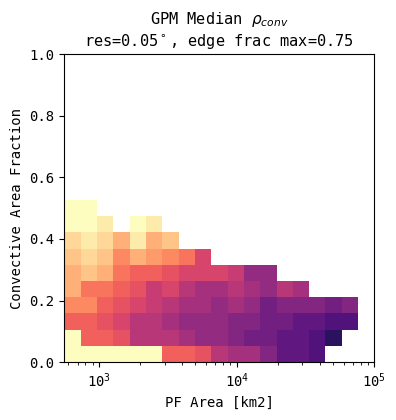

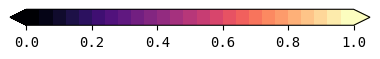

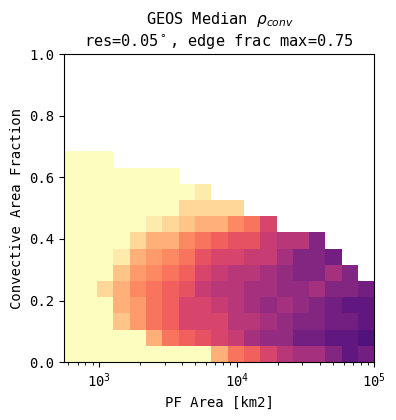

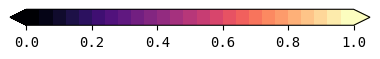

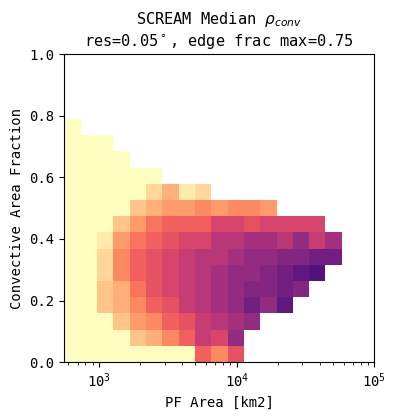

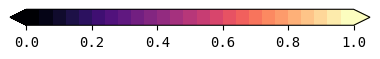

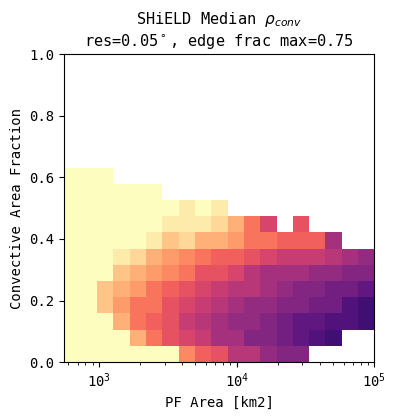

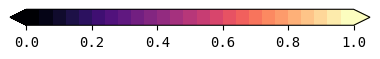

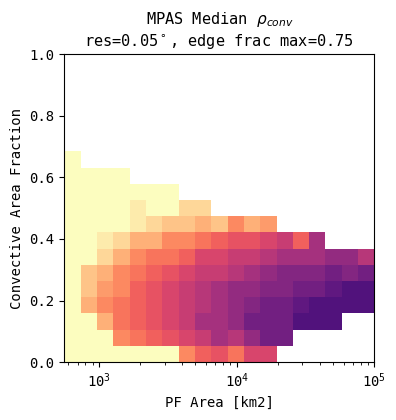

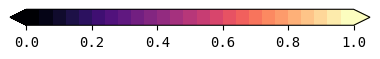

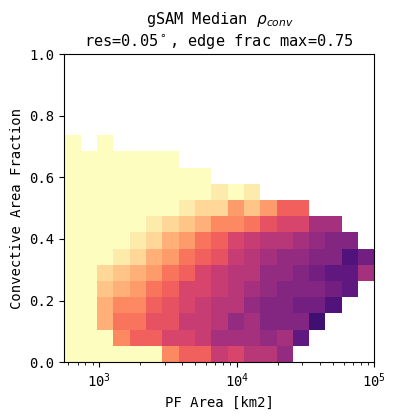

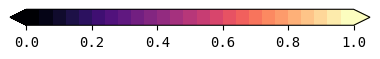

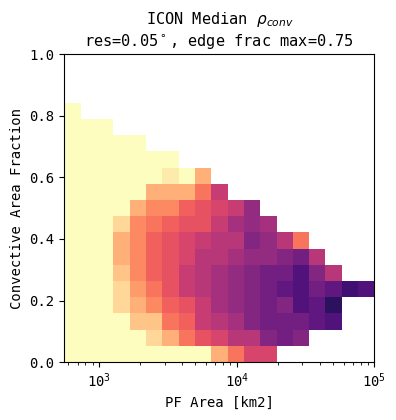

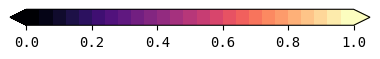

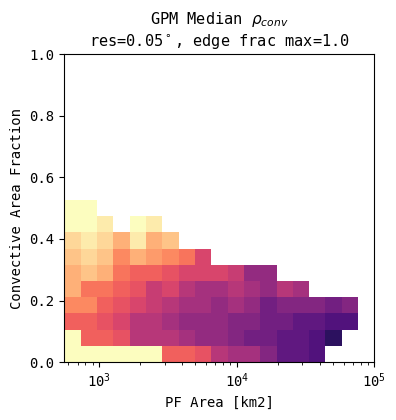

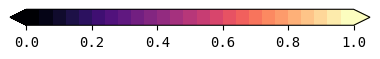

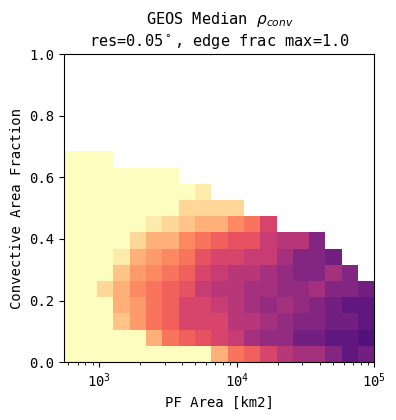

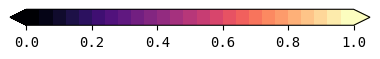

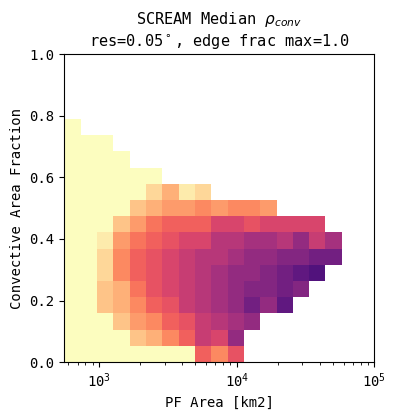

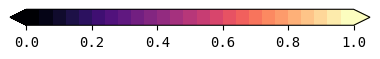

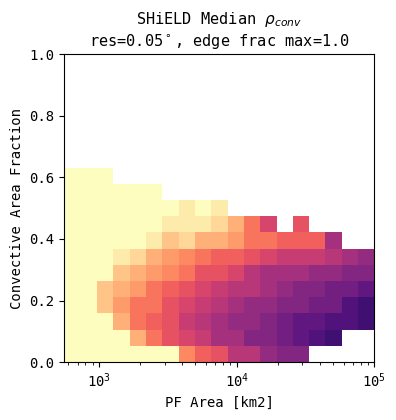

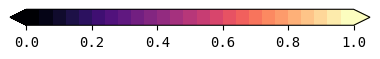

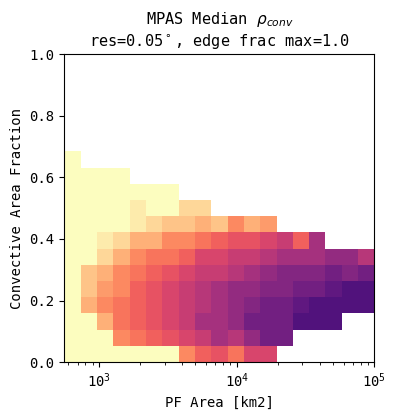

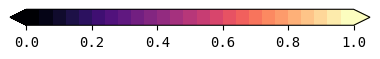

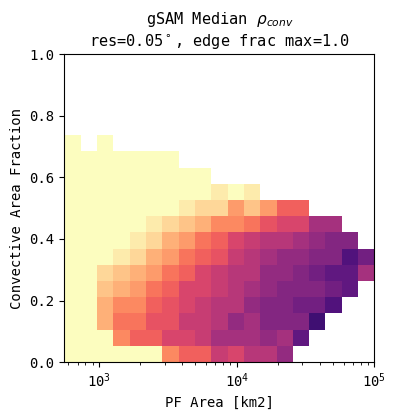

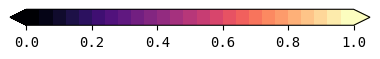

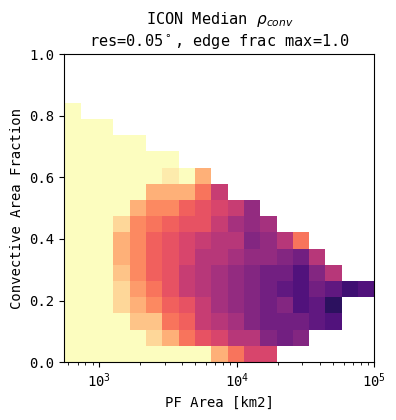

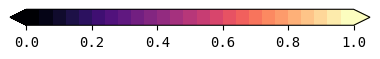

In [ ]:
# Sweep parameters

edge_frac_max_list = [0.0, 0.05, 0.25, 0.5, 0.75, 1.0]

for _EDGE_FRAC_MAX in edge_frac_max_list:

    # Load features (IMERG is native 0.1 deg, so it takes no res argument)
    _RES = "0p05"
    _ACCUM = "15min"
    _MAX_PR_MIN = 10.0
    _MAX_PR_MAX = SATURATED_MAXPR_MIN
    feature_stats_dict = {
        'GPM': load_gpm_feature_stats(threshold=1.0, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        # 'IMERG': load_imerg_feature_stats(threshold=1, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'GEOS': load_dyamond_feature_stats('GEOS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'MPAS': load_dyamond_feature_stats('MPAS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'gSAM': load_dyamond_feature_stats('gSAM-4km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
    }

    for source, df in feature_stats_dict.items():
        # Make the plot
        x_data = df['area_km2']
        y_data = df['px_ge_10mmhr'] / df['size_px']
        cmap = discrete_cmap(plt.cm.magma, 25)
        norm = colors.Normalize(vmin=0, vmax=1)

        def _quantile_diff(x):
            diff = np.nanquantile(x, 0.90) -  np.nanquantile(x, 0.1)

        fig, ax, cbar_fig, cbar_ax, data = plot_mean_stat(
            x_data=x_data,
            y_data=y_data,
            x_bins=x_bins,
            y_bins=y_bins,
            data_to_bin=df['largest_core_10mmhr_px']/df['px_ge_10mmhr'],
            statistic=lambda x: np.nanmedian(x) if x.size>=10 else np.nan,
            density=False,
            cmap=cmap,
            norm=norm,
            figsize=(4,4),
            return_data=True,
            return_colorbar_separate=True
        )
        ax.set_xscale('log')
        ax.set_xlabel('PF Area [km2]')
        ax.set_ylabel('Convective Area Fraction')
        ax.set_title(
            fr'{source} Median $\rho_{{conv}}$' '\n'
            fr'res={_RES_DEG}$^\circ$, edge frac max={_EDGE_FRAC_MAX}',
            fontsize=11,
        )
        plt.show()

# Sensitivity of MaxPr to Concentration

For each (area, convective fraction) bin, the difference in mean max precip between the features
whose convection sits in one core ($\rho = 1$) and those whose convection is spread over several
($\rho \leq 0.5$). The number reported per source is the **count-weighted** mean over the
significant bins; see the workspace below for why the unweighted one is not usable as a headline.

edge_frac_max=0.0: all sources cover month(s) ['02']


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:304: UserWarning: linewidths is ignored by contourf
  ax.contourf(


GPM $\Delta_{\rho\leq0.8}^{\rho\geq1.0}\,$MaxPr[%]
EdgeFracMax0.0 count-weighted significant-bin mean: 17.241 (unweighted: 28.668, 37/71 bins significant)


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:304: UserWarning: linewidths is ignored by contourf
  ax.contourf(


GEOS $\Delta_{\rho\leq0.8}^{\rho\geq1.0}\,$MaxPr[%]
EdgeFracMax0.0 count-weighted significant-bin mean: 8.235 (unweighted: 8.990, 44/146 bins significant)


...

MPAS $\Delta_{\rho\leq0.8}^{\rho\geq1.0}\,$MaxPr[%]
EdgeFracMax1.0 count-weighted significant-bin mean: 13.004 (unweighted: 14.002, 90/143 bins significant)


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:304: UserWarning: linewidths is ignored by contourf
  ax.contourf(


gSAM $\Delta_{\rho\leq0.8}^{\rho\geq1.0}\,$MaxPr[%]
EdgeFracMax1.0 count-weighted significant-bin mean: 10.866 (unweighted: 10.663, 80/147 bins significant)


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:304: UserWarning: linewidths is ignored by contourf
  ax.contourf(


ICON $\Delta_{\rho\leq0.8}^{\rho\geq1.0}\,$MaxPr[%]
EdgeFracMax1.0 count-weighted significant-bin mean: 20.104 (unweighted: 18.683, 89/154 bins significant)

shape: (42, 7)
┌───────────────┬────────┬────────────┬──────────┬─────────────┬────────────────────┬──────────────┐
│ edge_frac_max ┆ source ┆ n_features ┆ sig_bins ┆ filled_bins ┆ count_wtd_sig_mean ┆ sig_mean     │
│ ---           ┆ ---    ┆ ---        ┆ ---      ┆ ---         ┆ ---                ┆ (unweighted) │
│ f64           ┆ str    ┆ i64        ┆ i64      ┆ i64         ┆ f64                ┆ ---          │
│               ┆        ┆            ┆          ┆             ┆                    ┆ f64          │
╞═══════════════╪════════╪════════════╪══════════╪═════════════╪════════════════════╪══════════════╡
│ 0.0           ┆ GPM    ┆ 37568      ┆ 37       ┆ 71          ┆ 17.24              ┆ 28.67        │
│ 0.0           ┆ GEOS   ┆ 201710     ┆ 44       ┆ 146         ┆ 8.24               ┆ 8.99         │
│ 0.0           ┆ S

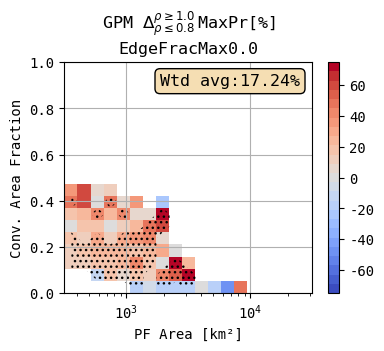

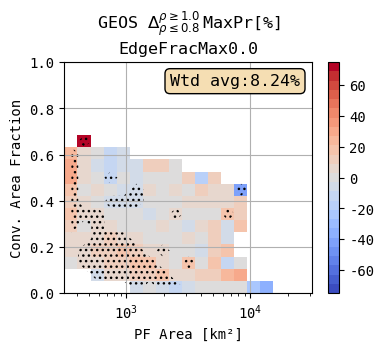

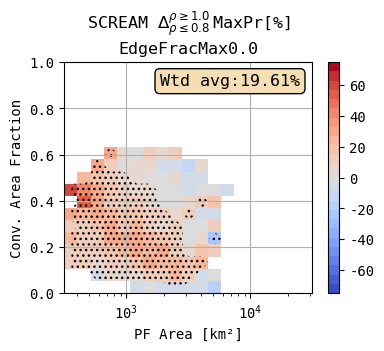

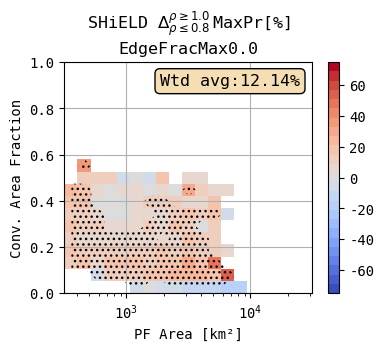

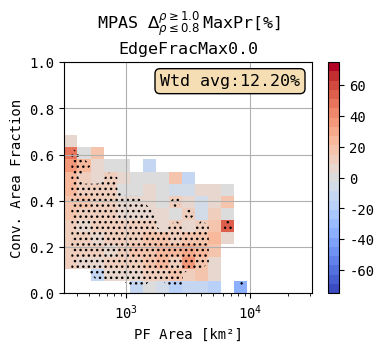

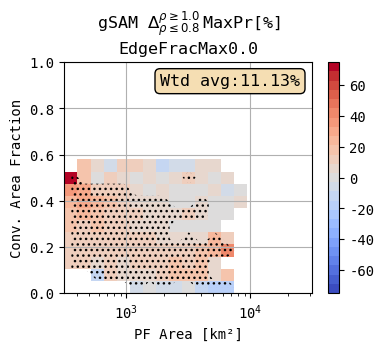

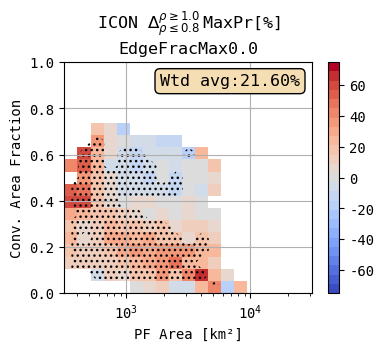

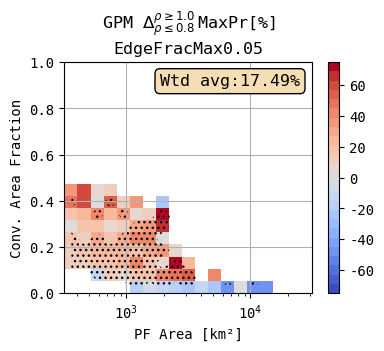

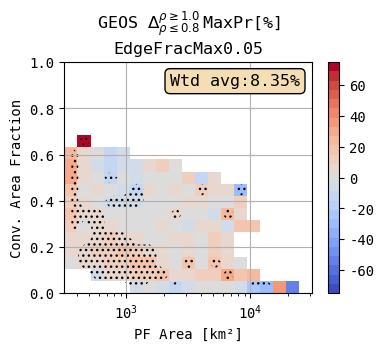

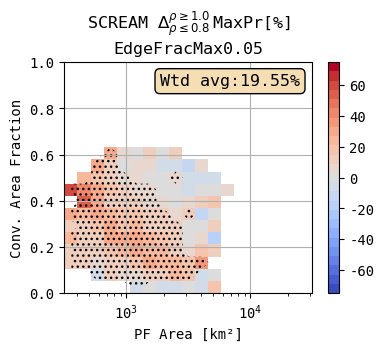

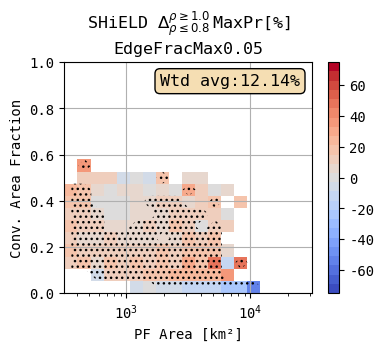

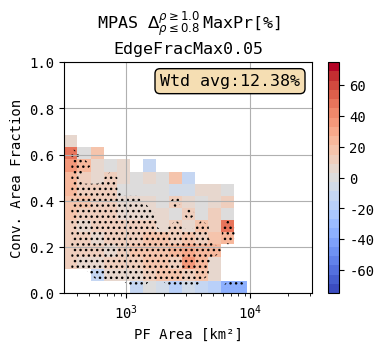

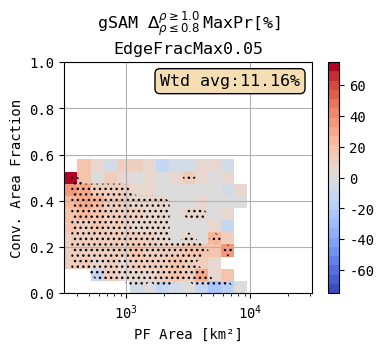

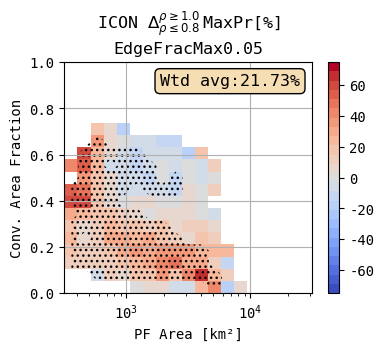

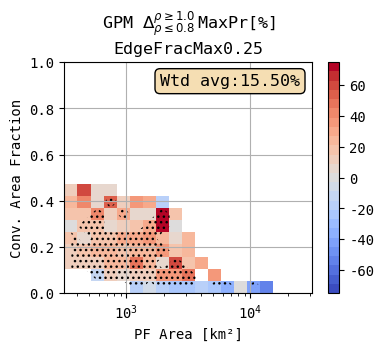

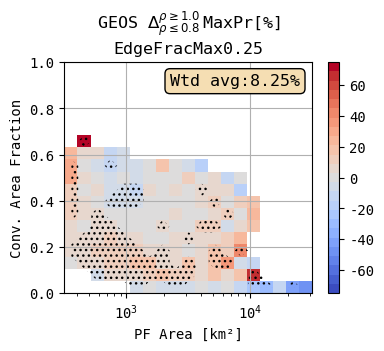

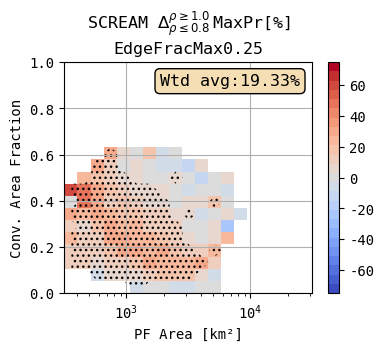

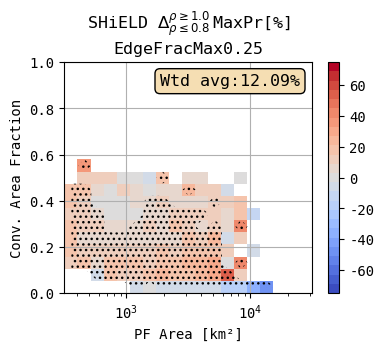

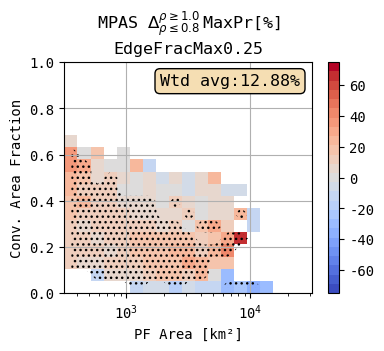

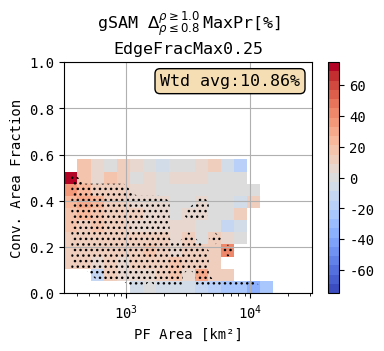

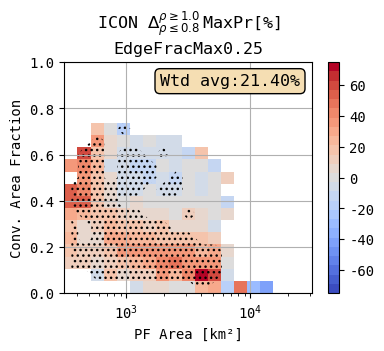

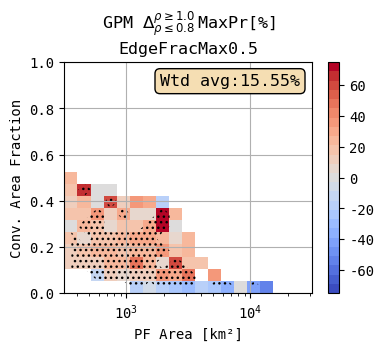

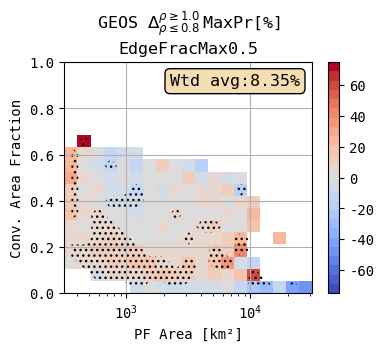

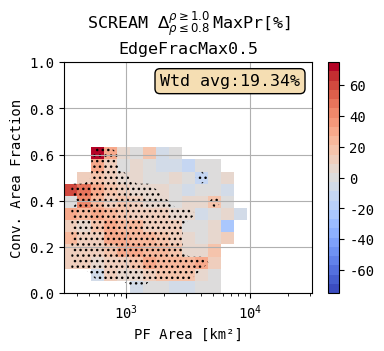

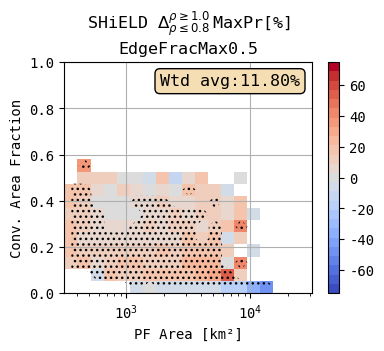

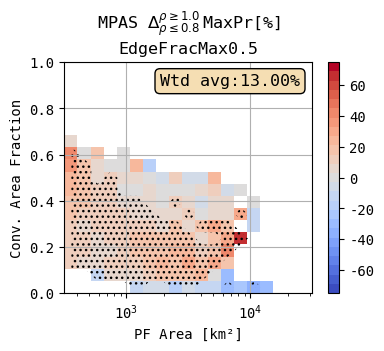

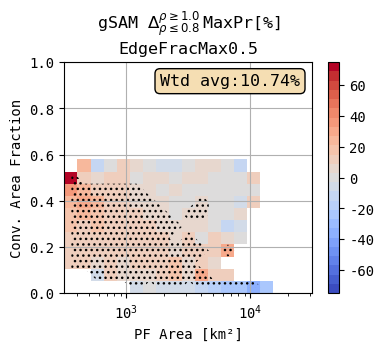

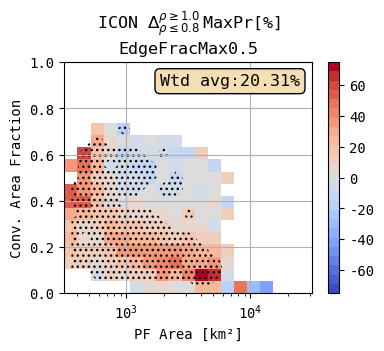

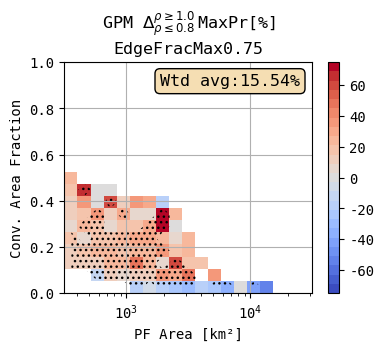

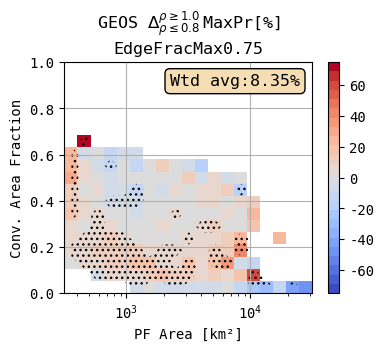

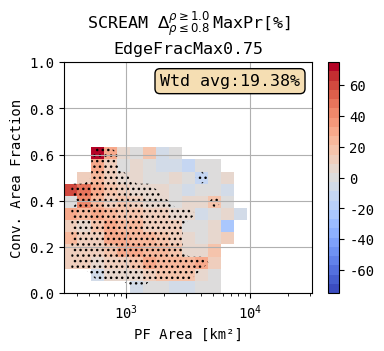

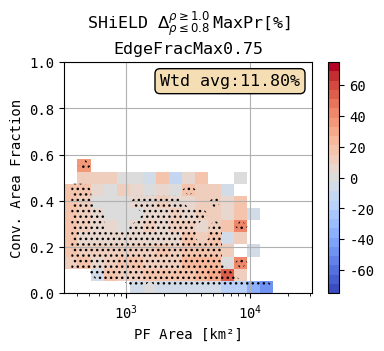

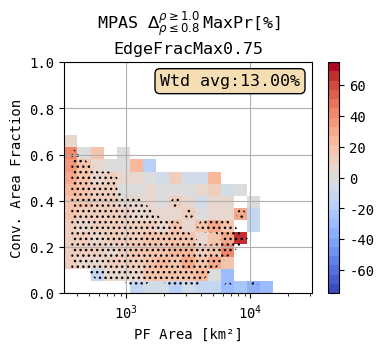

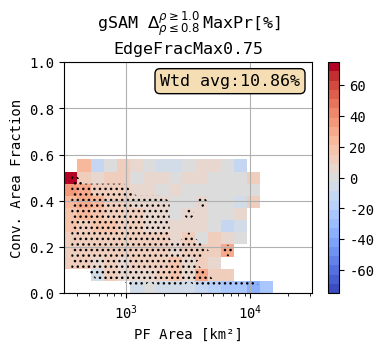

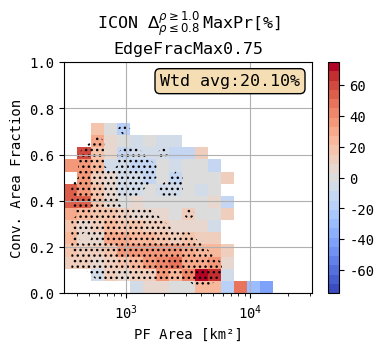

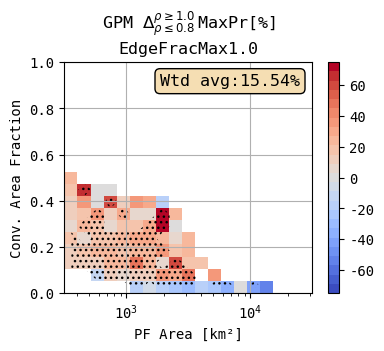

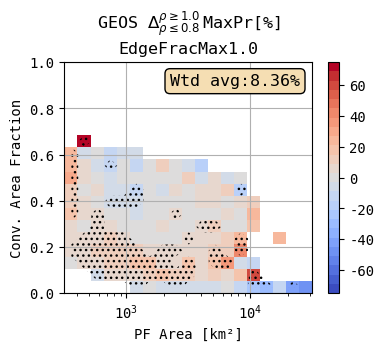

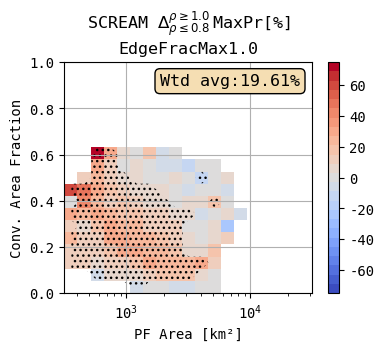

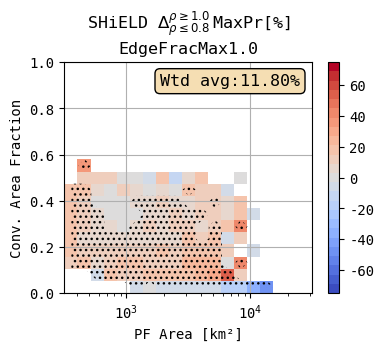

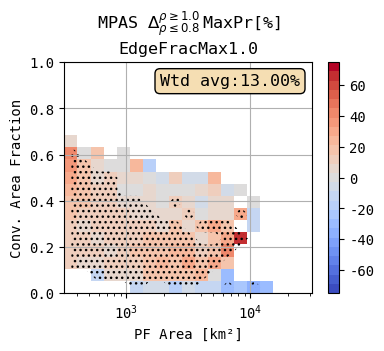

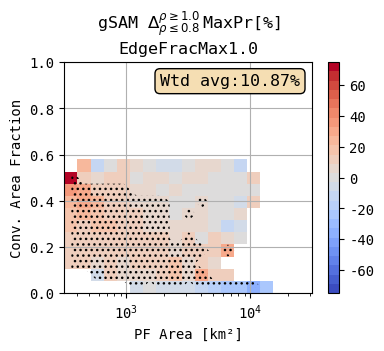

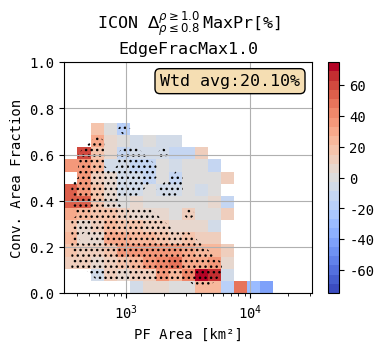

In [ ]:
# Sensitivity of MaxPr to concentration, with the four fixes from the workspace below:
#   1. the headline number is the count-weighted mean over significant bins, not the
#      unweighted one, which is selected on significance and drifts with sample size;
#   2. the rho split is by value (rho <= 0.5 vs rho == 1) rather than by decile, so the
#      ~70% of features tied at rho = 1 cannot be sorted into either group by row order;
#   3. features pinned at the 300 mm/hr GPM saturation cap are dropped, from the models too;
#   4. the sampling period is checked to be the same month in every source.

# Sweep parameters
_RES = "0p05"
_ACCUM = "15min"
_MAX_PR_MIN = 10.0
_MAX_PR_MAX = SATURATED_MAXPR_MIN  # drop the censored 300 mm/hr features (obs and models)
_RHO_LOW, _RHO_HIGH = 0.8, 1.0   # low = convection spread over several cores, high = one core
_GROUP_MIN = 5                     # min features in each rho group for a bin to be filled
X_BINS = np.logspace(2.5, 4.5, 20)
Y_BINS = np.linspace(0, 1, 20)
edge_frac_max_list = [0.0, 0.05, 0.25, 0.5, 0.75, 1.0]


def _months(df):
    """Months present in a feature table; handles both ISO strings and yyyymmdd floats."""
    return set(
        df["time"].cast(pl.Utf8).str.extract(r"^\d{4}-?(\d{2})", 1).drop_nulls().unique().to_list()
    )


delta_maxpr_summaries = {}

for _EDGE_FRAC_MAX in edge_frac_max_list:

    # Load features (IMERG is native 0.1 deg, so it takes no res argument)
    feature_stats_dict = {
        'GPM': load_gpm_feature_stats(threshold=1.0, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        # 'IMERG': load_imerg_feature_stats(threshold=1, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'GEOS': load_dyamond_feature_stats('GEOS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'MPAS': load_dyamond_feature_stats('MPAS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'gSAM': load_dyamond_feature_stats('gSAM-4km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
        'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, maxpr_max=_MAX_PR_MAX),
    }

    # Hold the sampling period fixed: comparing months would compare climatologies, and
    # the significant-bin mean is sensitive enough to sample size to hide that.
    months = {name: _months(df) for name, df in feature_stats_dict.items()}
    assert len(set(map(frozenset, months.values()))) == 1, f"Sources cover different months: {months}"
    print(f"edge_frac_max={_EDGE_FRAC_MAX}: all sources cover month(s) {sorted(next(iter(months.values())))}")

    sig_mean_values = {}                          # unweighted; kept only for continuity
    obs_weighted_sig_mean_values = {}             # count-weighted: the number to report
    sig_mean_over_gpm_region_values = {}
    obs_weighted_sig_mean_over_gpm_region_values = {}

    for model_name, df in feature_stats_dict.items():
        rho = df['largest_core_10mmhr_px'] / df['px_ge_10mmhr']
        sigma = df['px_ge_10mmhr'] / df['size_px']
        area = df['size_px'] * gpm_area_factor()
        maxpr = df['max_precip_mm_hr']
        bqd = BinnedQuantileDelta(
            data_to_sort=rho,
            data_to_diff=maxpr,
            x_data=area,
            y_data=sigma,
            x_bins=X_BINS,
            y_bins=Y_BINS,
            split='threshold',
            low_threshold=_RHO_LOW,
            high_threshold=_RHO_HIGH,
            percent_diff=True,
            samp_min=11,
            group_min=_GROUP_MIN,
            n_perm=200,
        )

        fig, ax, s, wtd_sig_mean, p, counts = bqd.plot(
            xlabel='PF Area [km²]',
            ylabel='Conv. Area Fraction',
            title=f'{model_name} $\\Delta_{{\\rho\\leq{_RHO_LOW}}}^{{\\rho\\geq{_RHO_HIGH}}}\\,$MaxPr[%]\nEdgeFracMax{_EDGE_FRAC_MAX}',
            cmap=discrete_cmap(plt.cm.coolwarm, 25),
            norm=colors.TwoSlopeNorm(vmin=-75, vcenter=0, vmax=75),
            return_p=True,
            return_counts=True,
        )

        summary = BinnedQuantileDelta.summarise(s, p, counts)
        delta_maxpr_summaries[(_EDGE_FRAC_MAX, model_name)] = summary

        obs_weighted_sig_mean_values[model_name] = wtd_sig_mean
        sig_mean_values[model_name] = summary['sig_mean']

        # GPM is loaded first, so its significant bins define the region every model is
        # then averaged over -- one common region rather than each model's own.
        if model_name == "GPM":
            gpm_mask = (p <= 0.05) & ~np.isnan(s)

        in_region = gpm_mask & ~np.isnan(s) & ~np.isnan(counts)
        sig_mean_over_gpm_region_values[model_name] = np.nanmean(s[in_region])
        obs_weighted_sig_mean_over_gpm_region_values[model_name] = float(np.ma.average(
            np.ma.masked_array(s, ~in_region),
            weights=np.ma.masked_array(counts, ~in_region),
        ))

        save_figure(fig, f'DeltaMaxPr_{model_name}_EdgeFracMax{_EDGE_FRAC_MAX}_RhoHigh_{_RHO_HIGH}_RhoLow_{_RHO_LOW}.pdf')

# Headline table: the count-weighted significant-bin mean, with the unstable unweighted
# mean alongside so the difference between the two stays visible.
delta_maxpr_table = pl.DataFrame([
    {
        "edge_frac_max": edge,
        "source": name,
        "n_features": int(d["n_features"]),
        "sig_bins": d["sig_bins"],
        "filled_bins": d["filled_bins"],
        "count_wtd_sig_mean": round(d["count_weighted_sig_mean"], 2),
        "sig_mean (unweighted)": round(d["sig_mean"], 2),
    }
    for (edge, name), d in delta_maxpr_summaries.items()
])
print()
print(delta_maxpr_table)

# The table spans the whole edge_frac_max sweep, so the filename carries only the rho
# thresholds -- the one setting that changes what the delta means -- to match the figures.
save_table(delta_maxpr_table, f'DeltaMaxPr_summary_RhoHigh_{_RHO_HIGH}_RhoLow_{_RHO_LOW}.csv')


In [ ]:
# Sensitivity of the headline number to the edge-fraction cut: one line per source,
# the count-weighted significant-bin mean against edge_frac_max. Reads
# delta_maxpr_summaries, so the sweep above has to have run first.

_sources = list(dict.fromkeys(name for _, name in delta_maxpr_summaries))
_edges = sorted({edge for edge, _ in delta_maxpr_summaries})
_x = np.arange(len(_edges))  # evenly spaced: the cuts are a sweep, not a continuous axis

_models = [n for n in _sources if n != "GPM"]
_model_colors = dict(zip(_models, plt.cm.viridis(np.linspace(0, 0.9, max(len(_models), 1)))))

fig, ax = plt.subplots(figsize=(5, 3.5))
for name in _sources:
    y = [
        delta_maxpr_summaries.get((edge, name), {}).get("count_weighted_sig_mean", np.nan)
        for edge in _edges
    ]
    if name == "GPM":  # observations: keep them readable against the model spread
        ax.plot(_x, y, "o-", color="k", lw=2.5, ms=6, label=name, zorder=3)
    else:
        ax.plot(_x, y, "o-", color=_model_colors[name], lw=1.5, ms=4, label=name)

ax.axhline(0, color="0.6", lw=0.8, zorder=0)
ax.set_xticks(_x)
ax.set_xticklabels([f"{e:g}" for e in _edges])
ax.set_xlabel("edge_frac_max")
ax.set_ylabel(
    f"$\\Delta_{{\\rho\\leq{_RHO_LOW}}}^{{\\rho\\geq{_RHO_HIGH}}}\\,$MaxPr [%]\n"
    "count-weighted over significant bins"
)
ax.set_title("Sensitivity of $\\Delta$MaxPr to the edge-fraction cut")
ax.legend(fontsize=7, ncol=2, frameon=False)
fig.tight_layout()

save_figure(fig, "DeltaMaxPr_vs_EdgeFracMax.pdf")

# Why the $\rho$ split is by value and not by quantile

$\rho = $ `largest_core_10mmhr_px / px_ge_10mmhr` is heavily tied: most features carry all
their convective pixels in a single core, so $\rho$ is *exactly* 1. Sorting on a variable
that cannot tell those features apart means the bottom/top decile groups are filled by row
order, not by $\rho$. The cells below quantify that, at one edge-fraction cut and on the
same bins and thresholds as the sweep above:

1. **Group sizes** — how much of the sample sits exactly at $\rho = 1$, how much below
   $\rho = 0.8$, and how those natural groups compare with a 10% decile.
2. **Ill-defined splits** — per bin, how much of each decile group carries a $\rho$ value
   that also occurs outside the group, i.e. how much of the group is interchangeable with
   features that were left out, and in how many bins the two groups share a $\rho$ value
   outright (there the split compares $\rho = 1$ with $\rho = 1$).
3. **Row-order sensitivity** — the headline number recomputed under many random row
   orders. The decile split moves; the threshold split cannot move, because the groups are
   defined by value.

rho groups: low <= 0.8, high >= 1; edge_frac_max=0
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/RhoGroupSizes_EdgeFracMax0.0.pdf as PDF ...
shape: (7, 7)
┌────────┬────────────┬─────────┬────────┬───────────────────┬──────────┬────────┐
│ source ┆ n_features ┆ rho<0.8 ┆ rho==1 ┆ tie mass / decile ┆ rho<=0.8 ┆ rho>=1 │
│ ---    ┆ ---        ┆ ---     ┆ ---    ┆ ---               ┆ ---      ┆ ---    │
│ str    ┆ i64        ┆ f64     ┆ f64    ┆ f64               ┆ f64      ┆ f64    │
╞════════╪════════════╪═════════╪════════╪═══════════════════╪══════════╪════════╡
│ GPM    ┆ 57678      ┆ 0.289   ┆ 0.681  ┆ 6.8               ┆ 0.298    ┆ 0.681  │
│ GEOS   ┆ 314555     ┆ 0.14    ┆ 0.819  ┆ 8.2               ┆ 0.148    ┆ 0.819  │
│ SCREAM ┆ 628992     ┆ 0.105   ┆ 0.859  ┆ 8.6               ┆ 0.112    ┆ 0.859  │
│ SHiELD ┆ 224302     ┆ 0.177   ┆ 0.775  ┆ 7.7               ┆ 0.187    ┆ 0.775  │
│ MPAS   ┆ 211029     ┆ 0.224   ┆ 0.722  ┆ 7.2               ┆ 0.236 

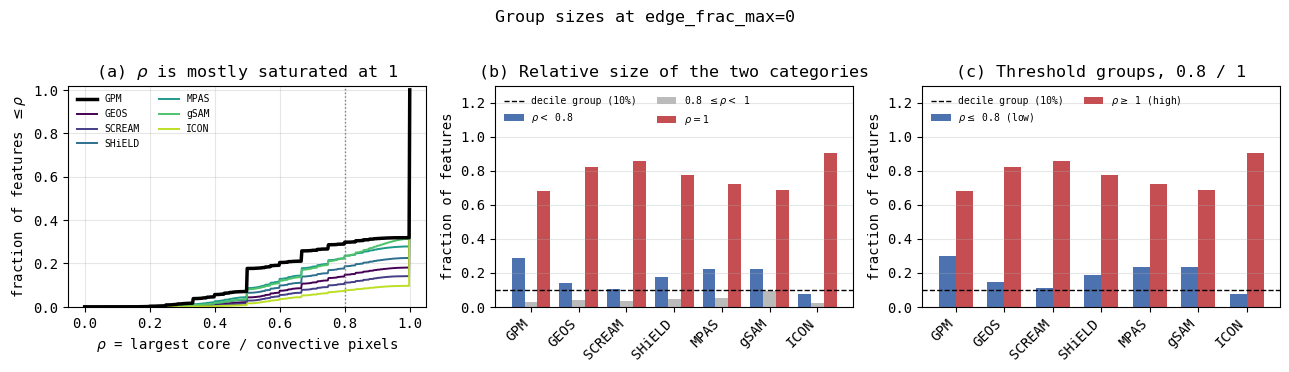

In [4]:
# Diagnostic 1: how big are the rho groups the two methods actually compare?
# Loads its own copy of the features at one edge-fraction cut so it does not depend on
# whatever the sweep loop left behind. The settings follow the sweep when that cell has
# run, and fall back to the values below otherwise, so this block and the two after it
# also run on their own straight after the imports cell.

def _diag_param(name, default):
    """The sweep's setting if it is defined, else `default`."""
    return globals().get(name, default)


_DIAG_RES = _diag_param('_RES', '0p05')
_DIAG_ACCUM = _diag_param('_ACCUM', '15min')
_DIAG_MAX_PR_MIN = _diag_param('_MAX_PR_MIN', 10.0)
_DIAG_MAX_PR_MAX = _diag_param('_MAX_PR_MAX', SATURATED_MAXPR_MIN)
_DIAG_RHO_LOW = _diag_param('_RHO_LOW', 0.8)
_DIAG_RHO_HIGH = _diag_param('_RHO_HIGH', 1.0)
_DIAG_GROUP_MIN = _diag_param('_GROUP_MIN', 5)
_DIAG_X_BINS = _diag_param('X_BINS', np.logspace(2.5, 4.5, 20))
_DIAG_Y_BINS = _diag_param('Y_BINS', np.linspace(0, 1, 20))

_DIAG_EDGE_FRAC_MAX = 0.0
_DIAG_SAMP_MIN = 11                     # bin-level minimum, as in the sweep
_DIAG_Q = 0.1                           # the old split: bottom and top decile
_DIAG_N_ORDERS = 20                     # random row orders used by diagnostic 3
_DIAG_RHO_SPREAD = 0.8                  # "convection spread over several cores" cut

diag_feature_stats = {
    'GPM': load_gpm_feature_stats(threshold=1.0, res=_DIAG_RES, edge_frac_max=_DIAG_EDGE_FRAC_MAX, maxpr_min=_DIAG_MAX_PR_MIN, maxpr_max=_DIAG_MAX_PR_MAX),
    'GEOS': load_dyamond_feature_stats('GEOS-3km', accum=_DIAG_ACCUM, res=_DIAG_RES, edge_frac_max=_DIAG_EDGE_FRAC_MAX, maxpr_min=_DIAG_MAX_PR_MIN, maxpr_max=_DIAG_MAX_PR_MAX),
    'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum=_DIAG_ACCUM, res=_DIAG_RES, edge_frac_max=_DIAG_EDGE_FRAC_MAX, maxpr_min=_DIAG_MAX_PR_MIN, maxpr_max=_DIAG_MAX_PR_MAX),
    'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum=_DIAG_ACCUM, res=_DIAG_RES, edge_frac_max=_DIAG_EDGE_FRAC_MAX, maxpr_min=_DIAG_MAX_PR_MIN, maxpr_max=_DIAG_MAX_PR_MAX),
    'MPAS': load_dyamond_feature_stats('MPAS-3km', accum=_DIAG_ACCUM, res=_DIAG_RES, edge_frac_max=_DIAG_EDGE_FRAC_MAX, maxpr_min=_DIAG_MAX_PR_MIN, maxpr_max=_DIAG_MAX_PR_MAX),
    'gSAM': load_dyamond_feature_stats('gSAM-4km', accum=_DIAG_ACCUM, res=_DIAG_RES, edge_frac_max=_DIAG_EDGE_FRAC_MAX, maxpr_min=_DIAG_MAX_PR_MIN, maxpr_max=_DIAG_MAX_PR_MAX),
    'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum=_DIAG_ACCUM, res=_DIAG_RES, edge_frac_max=_DIAG_EDGE_FRAC_MAX, maxpr_min=_DIAG_MAX_PR_MIN, maxpr_max=_DIAG_MAX_PR_MAX),
}
print(f'rho groups: low <= {_DIAG_RHO_LOW:g}, high >= {_DIAG_RHO_HIGH:g}; '
      f'edge_frac_max={_DIAG_EDGE_FRAC_MAX:g}')

_DIAG_SOURCES = list(diag_feature_stats)
_diag_color = dict(zip(
    [n for n in _DIAG_SOURCES if n != 'GPM'],
    plt.cm.viridis(np.linspace(0, 0.9, max(len(_DIAG_SOURCES) - 1, 1))),
))
_diag_color['GPM'] = 'k'


def _diag_fields(df):
    """rho, max precip, PF area and convective area fraction as plain numpy arrays."""
    rho = (df['largest_core_10mmhr_px'] / df['px_ge_10mmhr']).to_numpy().astype(float)
    maxpr = df['max_precip_mm_hr'].to_numpy().astype(float)
    area = (df['size_px'] * gpm_area_factor()).to_numpy().astype(float)
    caf = (df['px_ge_10mmhr'] / df['size_px']).to_numpy().astype(float)
    return rho, maxpr, area, caf


def _diag_bin_groups(area, caf, x_bins=None, y_bins=None):
    """Group features into the (area, CAF) grid the sweep uses.

    Returns (rows, bin_id, flat_bin, start, count): `rows` indexes the features that fall
    on the grid, ordered so each bin's rows are contiguous; bin k occupies
    rows[start[k]:start[k] + count[k]] and lives at flat index flat_bin[k] of the
    (ny, nx) grid. Doing the binning here rather than through binned_statistic_2d is what
    lets the cells below re-split a bin many times cheaply.
    """
    x_bins = _DIAG_X_BINS if x_bins is None else x_bins
    y_bins = _DIAG_Y_BINS if y_bins is None else y_bins
    nx, ny = len(x_bins) - 1, len(y_bins) - 1
    ix = np.digitize(area, x_bins) - 1
    iy = np.digitize(caf, y_bins) - 1
    ix = np.where(area == x_bins[-1], nx - 1, ix)   # scipy puts the right edge in the last bin
    iy = np.where(caf == y_bins[-1], ny - 1, iy)
    on_grid = (
        (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)
        & np.isfinite(area) & np.isfinite(caf)
    )
    rows = np.flatnonzero(on_grid)
    bin_id = (iy * nx + ix)[rows]
    order = np.argsort(bin_id, kind='stable')
    rows, bin_id = rows[order], bin_id[order]
    flat_bin, start = np.unique(bin_id, return_index=True)
    count = np.diff(np.append(start, len(bin_id)))
    return rows, bin_id, flat_bin, start, count


def _diag_to_grid(values, flat_bin, x_bins=None, y_bins=None):
    """Scatter per-bin values back onto the (ny, nx) grid, NaN where unfilled."""
    x_bins = _DIAG_X_BINS if x_bins is None else x_bins
    y_bins = _DIAG_Y_BINS if y_bins is None else y_bins
    grid = np.full((len(y_bins) - 1) * (len(x_bins) - 1), np.nan)
    grid[flat_bin] = values
    return grid.reshape(len(y_bins) - 1, len(x_bins) - 1)


# --- group sizes -----------------------------------------------------------------
diag_group_sizes = {}
for name, df in diag_feature_stats.items():
    rho, _, _, _ = _diag_fields(df)
    rho = rho[np.isfinite(rho)]
    diag_group_sizes[name] = {
        'n_features': rho.size,
        'rho_eq_1': float(np.mean(rho == 1.0)),
        'rho_lt_spread': float(np.mean(rho < _DIAG_RHO_SPREAD)),
        'rho_mid': float(np.mean((rho >= _DIAG_RHO_SPREAD) & (rho < 1.0))),
        'rho_le_low': float(np.mean(rho <= _DIAG_RHO_LOW)),
        'rho_ge_high': float(np.mean(rho >= _DIAG_RHO_HIGH)),
        'rho': rho,
    }

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# (a) the tie mass at rho = 1 is what breaks the quantile split
ax = axes[0]
_rho_grid = np.linspace(0, 1, 501)
for name in _DIAG_SOURCES:
    rho_sorted = np.sort(diag_group_sizes[name]['rho'])
    ecdf = np.searchsorted(rho_sorted, _rho_grid, side='right') / rho_sorted.size
    ax.plot(_rho_grid, ecdf, color=_diag_color[name], lw=2.5 if name == 'GPM' else 1.4,
            label=name, zorder=3 if name == 'GPM' else 2)
ax.axvline(_DIAG_RHO_SPREAD, color='0.5', ls=':', lw=1)
ax.set_xlabel(r'$\rho$ = largest core / convective pixels')
ax.set_ylabel(r'fraction of features $\leq \rho$')
ax.set_title(r'(a) $\rho$ is mostly saturated at 1')
ax.set_ylim(0, 1.02)
ax.legend(fontsize=7, ncol=2, frameon=False, loc='upper left')
ax.grid(alpha=0.3)

# (b) the categories asked for: spread convection vs a single core
ax = axes[1]
_x = np.arange(len(_DIAG_SOURCES))
_w = 0.27
_cats = [
    (rf'$\rho <$ {_DIAG_RHO_SPREAD:g}', 'rho_lt_spread', '#4c72b0'),
    (rf'{_DIAG_RHO_SPREAD:g} $\leq \rho <$ 1', 'rho_mid', '#bbbbbb'),
    (r'$\rho = 1$', 'rho_eq_1', '#c44e52'),
]
for i, (label, key, color) in enumerate(_cats):
    ax.bar(_x + (i - 1) * _w, [diag_group_sizes[n][key] for n in _DIAG_SOURCES],
           _w, color=color, label=label)
ax.axhline(_DIAG_Q, color='k', ls='--', lw=1,
           label=f'decile group ({_DIAG_Q:.0%})')
ax.set_xticks(_x)
ax.set_xticklabels(_DIAG_SOURCES, rotation=45, ha='right')
ax.set_ylabel('fraction of features')
ax.set_title('(b) Relative size of the two categories')
ax.set_ylim(0, 1.3)
ax.legend(fontsize=7, frameon=False, loc='upper left', ncol=2)
ax.grid(alpha=0.3, axis='y')

# (c) the groups the sweep actually compares, against the decile they replace
ax = axes[2]
for i, (label, key, color) in enumerate([
    (rf'$\rho \leq$ {_DIAG_RHO_LOW:g} (low)', 'rho_le_low', '#4c72b0'),
    (rf'$\rho \geq$ {_DIAG_RHO_HIGH:g} (high)', 'rho_ge_high', '#c44e52'),
]):
    ax.bar(_x + (i - 0.5) * 0.35, [diag_group_sizes[n][key] for n in _DIAG_SOURCES],
           0.35, color=color, label=label)
ax.axhline(_DIAG_Q, color='k', ls='--', lw=1, label=f'decile group ({_DIAG_Q:.0%})')
ax.set_xticks(_x)
ax.set_xticklabels(_DIAG_SOURCES, rotation=45, ha='right')
ax.set_ylabel('fraction of features')
ax.set_title(f'(c) Threshold groups, {_DIAG_RHO_LOW:g} / {_DIAG_RHO_HIGH:g}')
ax.set_ylim(0, 1.3)
ax.legend(fontsize=7, frameon=False, loc='upper left', ncol=2)
ax.grid(alpha=0.3, axis='y')

fig.suptitle(f'Group sizes at edge_frac_max={_DIAG_EDGE_FRAC_MAX:g}', y=1.02)
fig.tight_layout()
save_figure(fig, f'RhoGroupSizes_EdgeFracMax{_DIAG_EDGE_FRAC_MAX}.pdf')

print(pl.DataFrame([
    {
        'source': name,
        'n_features': d['n_features'],
        f'rho<{_DIAG_RHO_SPREAD:g}': round(d['rho_lt_spread'], 3),
        'rho==1': round(d['rho_eq_1'], 3),
        'tie mass / decile': round(d['rho_eq_1'] / _DIAG_Q, 1),
        f'rho<={_DIAG_RHO_LOW:g}': round(d['rho_le_low'], 3),
        f'rho>={_DIAG_RHO_HIGH:g}': round(d['rho_ge_high'], 3),
    }
    for name, d in diag_group_sizes.items()
]))
print(
    f"\nThe top decile holds {_DIAG_Q:.0%} of a bin, but {min(d['rho_eq_1'] for d in diag_group_sizes.values()):.0%}"
    f"-{max(d['rho_eq_1'] for d in diag_group_sizes.values()):.0%} of features are tied at rho = 1: "
    "which of them the decile keeps is decided by row order."
)

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/DecileAmbiguity_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/DecileAmbiguityMap_EdgeFracMax0.0.pdf as PDF ...
shape: (7, 8)
┌────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────────┐
│ source ┆ filled_bin ┆ high grp   ┆ low grp    ┆ groups     ┆ mean inter ┆ mean inter ┆ count-wtd │
│ ---    ┆ s          ┆ ambiguous  ┆ ambiguous  ┆ share rho  ┆ changeable ┆ changeable ┆ interchan │
│ str    ┆ ---        ┆ [%]        ┆ [%]        ┆ [%]        ┆ (high)     ┆ (low)      ┆ geable    │
│        ┆ i64        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ (hig…     │
│        ┆            ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ ---       │
│        ┆            ┆            ┆            ┆            ┆            ┆            ┆ f64       │
╞════════╪════════════╪═══════════

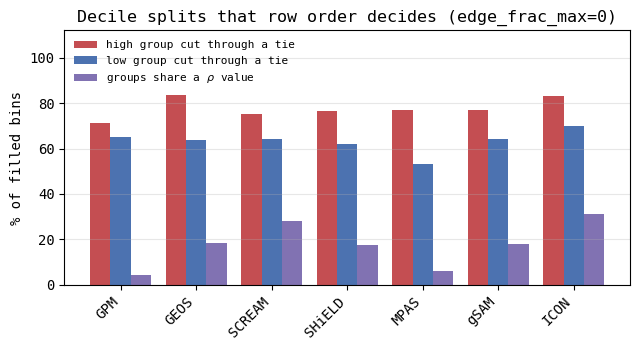

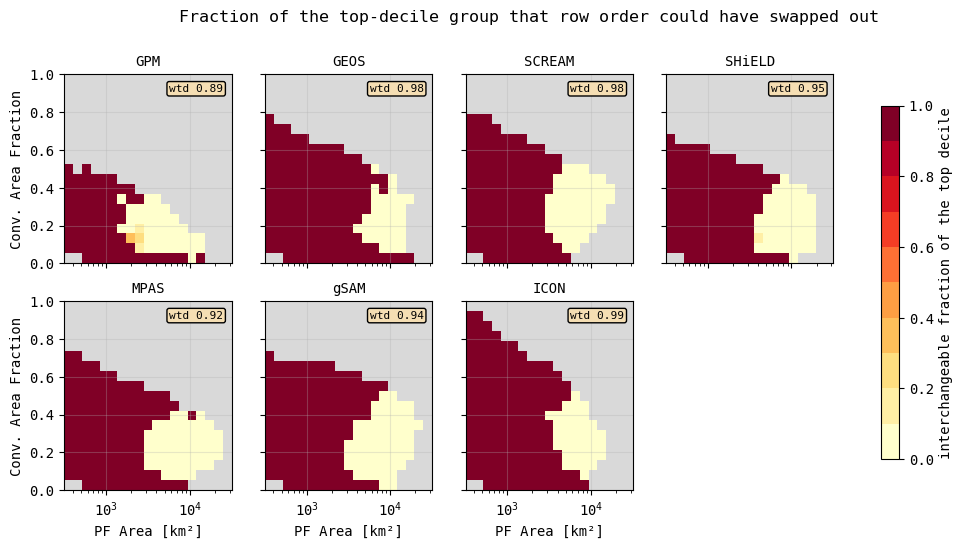

In [5]:
# Diagnostic 2: in how many bins is the decile difference not well defined?
# A decile group is ill defined when its boundary falls inside a run of tied rho: the
# members carrying the boundary value are interchangeable with features that were left
# out, so which of them the group holds is fixed by row order alone. The extreme case is
# the two groups sharing a rho value, where the split compares rho = 1 against rho = 1.

def _diag_decile_ambiguity(rho, area, caf, q=None, samp_min=None, seed=0):
    """Per-bin ambiguity of the decile split on the (area, CAF) grid.

    Returns grids of the interchangeable fraction of the high and low groups, a flag for
    bins whose two groups share a rho value, and the bin counts. Ties are ordered by a
    random key, which stands in for the arbitrary row order the quantile split inherits.
    """
    q = _DIAG_Q if q is None else q
    samp_min = _DIAG_SAMP_MIN if samp_min is None else samp_min
    rows, bin_id, flat_bin, start, count = _diag_bin_groups(area, caf)
    rho_rows = rho[rows]
    key = np.random.default_rng(seed).random(rows.size)
    order = np.lexsort((key, rho_rows, bin_id))
    r = rho_rows[order]

    amb_high = np.full(flat_bin.size, np.nan)
    amb_low = np.full(flat_bin.size, np.nan)
    shared = np.full(flat_bin.size, np.nan)
    for k, (s, n) in enumerate(zip(start, count)):
        if n < samp_min:
            continue
        li1, hi0 = int(round(q * n)), int(round((1 - q) * n))
        if li1 < 1 or n - hi0 < 1:
            continue
        rb = r[s:s + n]
        lo, hi = rb[:li1], rb[hi0:]
        # a member is interchangeable if its rho value also occurs outside its own group
        amb_high[k] = np.count_nonzero(hi <= rb[hi0 - 1]) / hi.size
        amb_low[k] = np.count_nonzero(lo >= rb[li1]) / lo.size
        shared[k] = float(lo[-1] >= hi[0])
    return {
        'amb_high': _diag_to_grid(amb_high, flat_bin),
        'amb_low': _diag_to_grid(amb_low, flat_bin),
        'shared': _diag_to_grid(shared, flat_bin),
        'counts': _diag_to_grid(count.astype(float), flat_bin),
    }


diag_ambiguity = {}
for name, df in diag_feature_stats.items():
    rho, maxpr, area, caf = _diag_fields(df)
    diag_ambiguity[name] = _diag_decile_ambiguity(rho, area, caf)

# --- how many bins are affected -------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 3.6))
_x = np.arange(len(_DIAG_SOURCES))
_w = 0.27
_series = [
    ('high group cut through a tie', 'amb_high', '#c44e52'),
    ('low group cut through a tie', 'amb_low', '#4c72b0'),
    ('groups share a $\\rho$ value', 'shared', '#8172b2'),
]
for i, (label, key, color) in enumerate(_series):
    frac = []
    for name in _DIAG_SOURCES:
        g = diag_ambiguity[name][key]
        filled = ~np.isnan(g)
        frac.append(100 * np.count_nonzero(g[filled] > 0) / filled.sum())
    ax.bar(_x + (i - 1) * _w, frac, _w, color=color, label=label)
ax.set_xticks(_x)
ax.set_xticklabels(_DIAG_SOURCES, rotation=45, ha='right')
ax.set_ylabel('% of filled bins')
ax.set_title(f'Decile splits that row order decides (edge_frac_max={_DIAG_EDGE_FRAC_MAX:g})')
ax.set_ylim(0, 112)
ax.legend(fontsize=8, frameon=False, loc='upper left')
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
save_figure(fig, f'DecileAmbiguity_EdgeFracMax{_DIAG_EDGE_FRAC_MAX}.pdf')

# --- and where on the plane -----------------------------------------------------
_ncol = 4
_nrow = int(np.ceil(len(_DIAG_SOURCES) / _ncol))
fig, axes = plt.subplots(_nrow, _ncol, figsize=(3.1 * _ncol, 2.7 * _nrow), sharex=True, sharey=True)
_xm, _ym = np.meshgrid(_DIAG_X_BINS, _DIAG_Y_BINS)
for ax, name in zip(axes.ravel(), _DIAG_SOURCES):
    g = diag_ambiguity[name]['amb_high']
    ax.set_facecolor('0.85')   # bins with too few features to split at all
    im = ax.pcolormesh(_xm, _ym, g, cmap=discrete_cmap(plt.cm.YlOrRd, 10), vmin=0, vmax=1)
    ax.set_xscale('log')
    ax.set_title(name, fontsize=10)
    ax.grid(alpha=0.3)
    w = diag_ambiguity[name]['counts']
    keep = ~np.isnan(g) & ~np.isnan(w)
    ax.text(0.95, 0.95, f'wtd {np.average(g[keep], weights=w[keep]):.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(facecolor='wheat', edgecolor='black', boxstyle='round,pad=0.2'))
for ax in axes.ravel()[len(_DIAG_SOURCES):]:
    ax.set_visible(False)
for ax in axes[-1, :]:
    ax.set_xlabel('PF Area [km²]')
for ax in axes[:, 0]:
    ax.set_ylabel('Conv. Area Fraction')
fig.colorbar(im, ax=axes, label='interchangeable fraction of the top decile', shrink=0.85)
fig.suptitle('Fraction of the top-decile group that row order could have swapped out', y=1.0)
save_figure(fig, f'DecileAmbiguityMap_EdgeFracMax{_DIAG_EDGE_FRAC_MAX}.pdf')

def _diag_wtd(grid, counts):
    keep = ~np.isnan(grid) & ~np.isnan(counts)
    return float(np.average(grid[keep], weights=counts[keep]))


print(pl.DataFrame([
    {
        'source': name,
        'filled_bins': int(np.count_nonzero(~np.isnan(d['amb_high']))),
        'high grp ambiguous [%]': round(100 * np.count_nonzero(np.nan_to_num(d['amb_high']) > 0)
                                        / np.count_nonzero(~np.isnan(d['amb_high'])), 1),
        'low grp ambiguous [%]': round(100 * np.count_nonzero(np.nan_to_num(d['amb_low']) > 0)
                                       / np.count_nonzero(~np.isnan(d['amb_low'])), 1),
        'groups share rho [%]': round(100 * np.nanmean(d['shared']), 1),
        'mean interchangeable (high)': round(float(np.nanmean(d['amb_high'])), 2),
        'mean interchangeable (low)': round(float(np.nanmean(d['amb_low'])), 2),
        'count-wtd interchangeable (high)': round(_diag_wtd(d['amb_high'], d['counts']), 2),
    }
    for name, d in diag_ambiguity.items()
]))
print(
    "\nWeighting by how many features a bin holds is what matters for the headline number: "
    "the bins that carry most of the weight are the ones where the top decile is entirely "
    "interchangeable."
)

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/RowOrderSensitivity_EdgeFracMax0.0.pdf as PDF ...
shape: (7, 8)
┌────────┬────────┬────────────┬────────────┬────────┬────────────┬───────────┬────────────────────┐
│ source ┆ decile ┆ decile min ┆ decile max ┆ decile ┆ decile std ┆ threshold ┆ threshold spread   │
│ ---    ┆ mean   ┆ ---        ┆ ---        ┆ spread ┆ ---        ┆ ---       ┆ ---                │
│ str    ┆ ---    ┆ f64        ┆ f64        ┆ ---    ┆ f64        ┆ f64       ┆ f64                │
│        ┆ f64    ┆            ┆            ┆ f64    ┆            ┆           ┆                    │
╞════════╪════════╪════════════╪════════════╪════════╪════════════╪═══════════╪════════════════════╡
│ GPM    ┆ 17.34  ┆ 14.16      ┆ 20.58      ┆ 6.43   ┆ 1.55       ┆ 15.39     ┆ 0.0                │
│ GEOS   ┆ 7.09   ┆ 6.42       ┆ 7.59       ┆ 1.18   ┆ 0.3        ┆ 5.13      ┆ 0.0                │
│ SCREAM ┆ 11.38  ┆ 11.1       ┆ 11.59      ┆ 0.49   

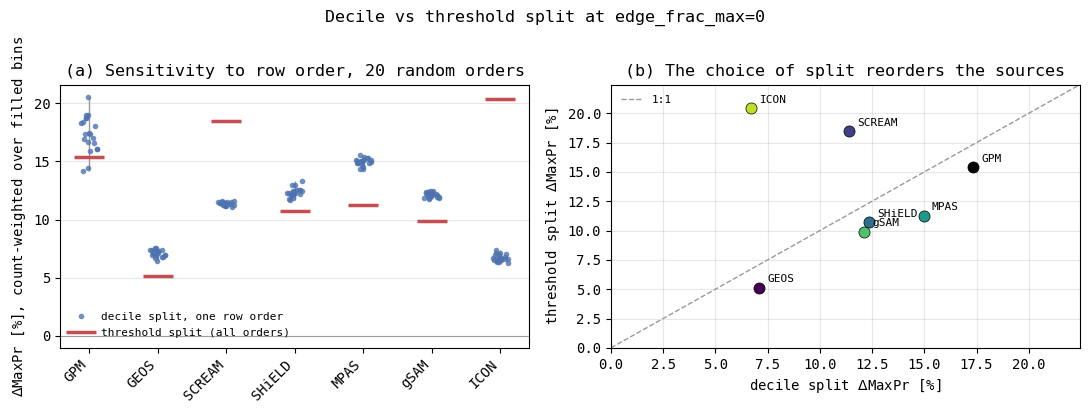

In [6]:
# Diagnostic 3: how much of the answer is row order?
# Both splits are recomputed under _DIAG_N_ORDERS random orderings of the tied features.
# The headline here is the count-weighted mean over *filled* bins rather than significant
# ones: the permutation test is the expensive part and significance selection would mix a
# second effect into the spread. The decile split moves with row order; the threshold
# split is invariant by construction, and the loop below re-runs it anyway to show that.

def _diag_delta_headlines(rho, maxpr, area, caf, seed):
    """(decile, threshold) count-weighted mean delta under one random tie order."""
    rows, bin_id, flat_bin, start, count = _diag_bin_groups(area, caf)
    rho_rows, maxpr_rows = rho[rows], maxpr[rows]
    key = np.random.default_rng(seed).random(rows.size)
    order = np.lexsort((key, rho_rows, bin_id))
    r, m = rho_rows[order], maxpr_rows[order]

    dec = np.full(flat_bin.size, np.nan)
    thr = np.full(flat_bin.size, np.nan)
    for k, (s, n) in enumerate(zip(start, count)):
        if n < _DIAG_SAMP_MIN:
            continue
        rb, mb = r[s:s + n], m[s:s + n]

        li1, hi0 = int(round(_DIAG_Q * n)), int(round((1 - _DIAG_Q) * n))
        if li1 >= 1 and n - hi0 >= 1:
            lo, hi = mb[:li1], mb[hi0:]
            dec[k] = 100 * (hi.mean() - lo.mean()) / lo.mean()

        lo, hi = mb[rb <= _DIAG_RHO_LOW], mb[rb >= _DIAG_RHO_HIGH]
        if lo.size >= _DIAG_GROUP_MIN and hi.size >= _DIAG_GROUP_MIN:
            thr[k] = 100 * (hi.mean() - lo.mean()) / lo.mean()

    w = count.astype(float)
    out = []
    for g in (dec, thr):
        k = ~np.isnan(g)
        out.append(float(np.average(g[k], weights=w[k])) if k.any() else np.nan)
    return out


diag_order_sensitivity = {}
for name, df in diag_feature_stats.items():
    rho, maxpr, area, caf = _diag_fields(df)
    pairs = [_diag_delta_headlines(rho, maxpr, area, caf, seed) for seed in range(_DIAG_N_ORDERS)]
    diag_order_sensitivity[name] = {
        'decile': np.array([p[0] for p in pairs]),
        'threshold': np.array([p[1] for p in pairs]),
    }

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4))
_x = np.arange(len(_DIAG_SOURCES))
_jitter = np.random.default_rng(1).uniform(-0.12, 0.12, _DIAG_N_ORDERS)
for i, name in enumerate(_DIAG_SOURCES):
    d = diag_order_sensitivity[name]['decile']
    t = diag_order_sensitivity[name]['threshold']
    ax.vlines(i, d.min(), d.max(), color='0.6', lw=1, zorder=1)
    ax.plot(i + _jitter, d, 'o', ms=4, mfc='#4c72b0', mec='none', alpha=0.8, zorder=2,
            label='decile split, one row order' if i == 0 else None)
    ax.plot(i, t.mean(), '_', ms=22, mew=2.5, color='#c44e52', zorder=3,
            label='threshold split (all orders)' if i == 0 else None)
ax.axhline(0, color='0.6', lw=0.8, zorder=0)
ax.set_xticks(_x)
ax.set_xticklabels(_DIAG_SOURCES, rotation=45, ha='right')
ax.set_ylabel(r'$\Delta$MaxPr [%], count-weighted over filled bins')
ax.set_title(f'(a) Sensitivity to row order, {_DIAG_N_ORDERS} random orders')
ax.legend(fontsize=8, frameon=False, loc='lower left')
ax.grid(alpha=0.3, axis='y')

# The two splits do not just differ by a constant: where the decile groups overlap most,
# the decile contrast is diluted towards zero, which reorders the sources.
_dec = np.array([diag_order_sensitivity[n]['decile'].mean() for n in _DIAG_SOURCES])
_thr = np.array([diag_order_sensitivity[n]['threshold'].mean() for n in _DIAG_SOURCES])
_lims = [0, 1.1 * max(_dec.max(), _thr.max())]
ax2.plot(_lims, _lims, color='0.6', lw=1, ls='--', label='1:1')
for name, dv, tv in zip(_DIAG_SOURCES, _dec, _thr):
    ax2.plot(dv, tv, 'o', ms=8, color=_diag_color[name], mec='k', mew=0.5)
    ax2.annotate(name, (dv, tv), textcoords='offset points', xytext=(6, 4), fontsize=8)
ax2.set_xlim(_lims)
ax2.set_ylim(_lims)
ax2.set_xlabel(r'decile split $\Delta$MaxPr [%]')
ax2.set_ylabel(r'threshold split $\Delta$MaxPr [%]')
ax2.set_title('(b) The choice of split reorders the sources')
ax2.legend(fontsize=8, frameon=False)
ax2.grid(alpha=0.3)

fig.suptitle(f'Decile vs threshold split at edge_frac_max={_DIAG_EDGE_FRAC_MAX:g}', y=1.02)
fig.tight_layout()
save_figure(fig, f'RowOrderSensitivity_EdgeFracMax{_DIAG_EDGE_FRAC_MAX}.pdf')

print(pl.DataFrame([
    {
        'source': name,
        'decile mean': round(float(d['decile'].mean()), 2),
        'decile min': round(float(d['decile'].min()), 2),
        'decile max': round(float(d['decile'].max()), 2),
        'decile spread': round(float(d['decile'].max() - d['decile'].min()), 2),
        'decile std': round(float(d['decile'].std()), 2),
        'threshold': round(float(d['threshold'].mean()), 2),
        'threshold spread': round(float(d['threshold'].max() - d['threshold'].min()), 6),
    }
    for name, d in diag_order_sensitivity.items()
]))
_rank = lambda v: np.argsort(np.argsort(v)).astype(float)
print(
    "\nThe threshold spread is 0 by construction: the groups are sets of rho values, so no "
    "reordering of tied features can move a feature between them."
    f"\nRank correlation of the two splits across sources: "
    f"{np.corrcoef(_rank(_dec), _rank(_thr))[0, 1]:.2f} -- they do not order the sources the same way."
)